# Kicker Model - 03 Modeling

Sequential modeling notebook building on `01_data_prep.ipynb`. Run data prep first to refresh `Model/Data/fg_attempts.csv` and `Model/Data/fg_nonattempts.csv`.


## Libraries


In [15]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(lme4)
  library(splines)
  library(splines2)
  library(yardstick)
  library(pROC)
  library(loo)
  library(ggplot2)
  library(readr)
  library(glmnet)
  library(glmmTMB)
})


## Configuration & Paths


In [16]:
PROJECT_ROOT <- if (requireNamespace("here", quietly = TRUE)) here::here() else getwd()
DATA_DIR <- file.path(PROJECT_ROOT, "Model", "Data")
METRICS_DIR <- file.path(PROJECT_ROOT, "Model", "Metrics")
METRICS_FIG_DIR <- file.path(METRICS_DIR, "figs")
RDS_DIR <- file.path(PROJECT_ROOT, "Model", "RDS")
TUNING_DIR <- file.path(PROJECT_ROOT, "Model", "Tuning")    

set.seed(42)

print(PROJECT_ROOT)
print(DATA_DIR)
print(METRICS_DIR)
print(METRICS_FIG_DIR)
print(RDS_DIR)

[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Data"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Metrics"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Metrics/figs"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/RDS"


## Load Prepared Data


In [17]:
fg_attempts <- readr::read_csv(file.path(DATA_DIR, "fg_attempts.csv"), show_col_types = FALSE)
fg_nonattempts <- readr::read_csv(file.path(DATA_DIR, "fg_nonattempts.csv"), show_col_types = FALSE)

nrow(fg_attempts)
head(fg_attempts %>% select(game_id, season, week, kick_distance, kick_result, kick_made, wind_z, temp_z, leverage_z))

nrow(fg_nonattempts)
head(fg_nonattempts %>% select(game_id, season, week, kick_distance, attempted, wind_z, temp_z, leverage_z))

colnames(fg_attempts)


[1] 23373

game_id,season,week,kick_distance,kick_result,kick_made,wind_z,temp_z,leverage_z
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2015_01_BAL_DEN,2015,1,57,made,1,1.154244,1.608162,0.6965373
2015_01_BAL_DEN,2015,1,56,made,1,1.154244,1.608162,0.6754065
2015_01_BAL_DEN,2015,1,52,made,1,1.154244,1.608162,0.3935023
2015_01_BAL_DEN,2015,1,43,made,1,1.154244,1.608162,0.6682452
2015_01_BAL_DEN,2015,1,33,made,1,1.154244,1.608162,-0.5565021
2015_01_BAL_DEN,2015,1,44,made,1,1.154244,1.608162,0.8853624


[1] 35

game_id,season,week,kick_distance,attempted,wind_z,temp_z,leverage_z
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2015_03_CIN_BAL,2015,3,25,0,0.9627370,0.52796984,0.3774298
2017_05_NYJ_CLE,2017,5,21,0,0.1967097,0.34793776,1.1896144
2017_09_ATL_CAR,2017,9,29,0,-0.5693176,-0.01212641,1.1479474
2019_08_TB_TEN,2019,8,45,0,-0.7608244,-0.13214779,0.9596308
2019_10_KC_TEN,2019,10,46,0,0.3882165,0.10789498,0.6238356
2019_12_DAL_NE,2019,12,32,0,1.7287642,-1.39237236,0.3863103


[1] "game_id"                    "play_id"                   
 [3] "old_game_id"                "season"                    
 [5] "week"                       "season_type"               
 [7] "playoffs"                   "qtr"                       
 [9] "game_date"                  "home_team"                 
[11] "away_team"                  "posteam"                   
[13] "defteam"                    "game_seconds_remaining"    
[15] "quarter_seconds_remaining"  "score_differential"        
[17] "yardline_100"               "ydstogo"                   
[19] "wp"                         "home_wp"                   
[21] "epa"                        "posteam_timeouts_remaining"
[23] "defteam_timeouts_remaining" "goal_to_go"                
[25] "is_ot"                      "roof"                      
[27] "surface"                    "temp"                      
[29] "wind"                       "weather"                   
[31] "stadium_id"                 "stadium"                   
[33] "location"                   "kick_distance"             
[35] "kicker_player_id"           "kicker_player_name"        
[37] "field_goal_result"          "extra_point_result"        
[39] "kick_result"                "is_pat"                    
[41] "attempted"                  "play_type_original"        
[43] "down"                       "prev_play_type"            
[45] "prev_desc"                  "prev_timeout"              
[47] "prev_timeout_team"          "prev_penalty"              
[49] "prev_incomplete"            "prev_out_bounds"           
[51] "prev_end_quarter"           "prev_two_min_warning"      
[53] "delta_secs"                 "l2m"                       
[55] "clock_running"              "iced"                      
[57] "birth_date"                 "rookie_season"             
[59] "kicker_age"                 "kicker_experience"         
[61] "roof_std"                   "indoors"                   
[63] "surface_std"                "is_turf"                   
[65] "high_altitude"              "weather_first"             
[67] "weather_clean"              "humidity"                  
[69] "is_snow_sleet"              "is_rain_showers"           
[71] "is_cloudy"                  "is_hazy_fog"               
[73] "wp_make_hat"                "wp_miss_hat"               
[75] "leverage"                   "wp_make_hat_rules"         
[77] "wp_miss_hat_rules"          "leverage_rules"            
[79] "pred_hat_post"              "wind_z"                    
[81] "temp_z"                     "humidity_z"                
[83] "kicker_age_z"               "kicker_experience_z"       
[85] "season_z"                   "kick_made"                 
[87] "eoh_urgency"                "eog_urgency"               
[89] "go_ahead"                   "to_tie"                    
[91] "close7"                     "leverage_z"

## Prepare Modeling Frames


In [18]:
fg_attempts <- fg_attempts %>%
  mutate(
    kicker_player_id = if_else(is.na(kicker_player_id), "UNKNOWN", kicker_player_id),
    stadium_id = if_else(is.na(stadium_id), "UNKNOWN", stadium_id),
    kick_made = if_else(!is.na(kick_made), kick_made, if_else(kick_result == "made", 1L, NA_integer_)),
    block_flag = if_else(kick_result == "blocked", 1L, 0L),
    kick_distance = as.numeric(kick_distance)
  )

fg_attempts_mm <- fg_attempts %>%
  filter(kick_result %in% c("made", "missed")) %>%
  mutate(
    kick_made = if_else(kick_result == "made", 1L, 0L),
    stadium_id = if_else(is.na(stadium_id), "UNKNOWN", stadium_id)
  )

fg_attempts_blocks <- fg_attempts %>%
  mutate(kick_made_block0 = case_when(
    kick_result == "made" ~ 1L,
    kick_result %in% c("missed", "blocked") ~ 0L,
    TRUE ~ NA_integer_
  ))


In [19]:
# --- Setup ---------------------------------------------------------------
library(dplyr)
library(tidyr)
library(purrr)
library(splines)
library(splines2)
library(pROC)

# Data slice: made/missed only
d0 <- fg_attempts_mm %>%
  filter(!is.na(kick_distance), !is.na(kick_made))

stopifnot(nrow(d0) > 0)

# === FIX: 11 bins at 5-yd steps (includes 65) ===========================
bin_breaks <- seq(15, 70, by = 5)  # 15,20,...,65,70  -> 11 bins
# right=FALSE → [a,b) except the last, which will be [65,70]
bin_labels <- levels(cut(15:69, breaks = bin_breaks, right = FALSE, include.lowest = TRUE))

# --- Model builders (M0 only: distance effect) ---------------------------
build_manual <- function(df) {
  bs <- splines2::bSpline(
    x = df$kick_distance,
    knots = c(25,35,45,55),
    degree = 3,
    intercept = FALSE,
    Boundary.knots = c(15,70)
  )
  colnames(bs) <- paste0("bs_", seq_len(ncol(bs)))
  dat <- bind_cols(df, as.data.frame(bs))
  form <- as.formula(paste("kick_made ~", paste(colnames(bs), collapse = " + ")))
  list(data = dat, formula = form)
}

build_ns4 <- function(df) {
  form <- kick_made ~ ns(kick_distance, df = 4, Boundary.knots = c(15,70))
  list(data = df, formula = form)
}

build_ns4_hinge60 <- function(df) {
  dat <- mutate(df, tail60 = pmax(kick_distance - 60, 0))
  form <- kick_made ~ ns(kick_distance, df = 4, Boundary.knots = c(15,70)) + tail60
  list(data = dat, formula = form)
}

# --- Fit & evaluate ------------------------------------------------------
fit_eval <- function(builder, label) {
  b <- builder(d0)
  m <- glm(b$formula, data = b$data, family = binomial())
  p <- as.numeric(predict(m, type = "response"))
  y <- b$data$kick_made

  auc_val <- as.numeric(pROC::auc(y, p))

  cal <- b$data %>%
    mutate(
      p_hat = p,
      dist_bin = cut(kick_distance, breaks = bin_breaks,
                     labels = bin_labels, include.lowest = TRUE, right = FALSE)
    ) %>%
    group_by(dist_bin) %>%
    summarise(
      n = n(),
      mean_pred = mean(p_hat),
      actual    = mean(kick_made),
      abs_err   = abs(mean_pred - actual),
      .groups = "drop"
    ) %>%
    mutate(model = label)

  list(label = label, model = m, auc = auc_val, cal = cal)
}

res <- list(
  fit_eval(build_manual,        "manual_bSpline"),
  fit_eval(build_ns4,           "natural_df4"),
  fit_eval(build_ns4_hinge60,   "natural_df4_hinge60")
)

# --- Summaries -----------------------------------------------------------
auc_tbl <- tibble::tibble(
  model = sapply(res, `[[`, "label"),
  AUC   = sapply(res, `[[`, "auc")
) %>% arrange(desc(AUC))
print(auc_tbl)

cal_tbl <- bind_rows(lapply(res, `[[`, "cal")) %>%
  arrange(match(dist_bin, bin_labels), model)
#print(cal_tbl, n = 300)

# Tail focus: the last two bins now exist
tail_tbl <- cal_tbl %>% filter(dist_bin %in% c("[60,65)", "[65,70]")) %>%
  arrange(dist_bin, desc(n), model)
tail_tbl

#Print the manual bin performance across all bins
cal_tbl %>% filter(model == "manual_bSpline")


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



# A tibble: 3 × 2
  model                 AUC
  <chr>               <dbl>
1 manual_bSpline      0.749
2 natural_df4         0.749
3 natural_df4_hinge60 0.749


dist_bin,n,mean_pred,actual,abs_err,model
<fct>,<int>,<dbl>,<dbl>,<dbl>,<chr>
"[60,65)",61,0.3937483,0.4098361,0.016087748,manual_bSpline
"[60,65)",61,0.5368468,0.4098361,0.127010698,natural_df4
"[60,65)",61,0.4680216,0.4098361,0.058185514,natural_df4_hinge60
"[65,70]",13,0.1512329,0.1538462,0.002613247,manual_bSpline
"[65,70]",13,0.4706326,0.1538462,0.316786407,natural_df4
"[65,70]",13,0.1180578,0.1538462,0.035788382,natural_df4_hinge60


dist_bin,n,mean_pred,actual,abs_err,model
<fct>,<int>,<dbl>,<dbl>,<dbl>,<chr>
"[15,20)",53,0.9999976,1.0000000,2.354239e-06,manual_bSpline
"[20,25)",1063,0.9950030,0.9943556,6.474401e-04,manual_bSpline
"[25,30)",1404,0.9770884,0.9743590,2.729406e-03,manual_bSpline
"[30,35)",13930,0.9523818,0.9525485,1.666624e-04,manual_bSpline
"[35,40)",1628,0.9161777,0.9189189,2.741222e-03,manual_bSpline
"[40,45)",1546,0.8375025,0.8376455,1.430050e-04,manual_bSpline
"[45,50)",1588,0.7593432,0.7544081,4.935115e-03,manual_bSpline
"[50,55)",1328,0.7131813,0.7251506,1.196933e-02,manual_bSpline
"[55,60)",457,0.6270434,0.6017505,2.529288e-02,manual_bSpline


## M0: Baseline GLM (distance-only)


### Logit link


In [20]:
# 1) Build manual B-spline basis (no intercept in the basis)
make_dist_basis <- function(x) {
  X <- splines2::bSpline(
    x = x,
    knots = c(25, 35, 45, 55),   # internal knots
    degree = 3,
    intercept = FALSE,           # keep model intercept separate
    Boundary.knots = c(15, 70)   # linear-like tails outside support
  )
  colnames(X) <- paste0("bs_", seq_len(ncol(X)))
  as.data.frame(X)
}

# 2) Add basis to your modeling frame
fg_attempts_m0 <- fg_attempts_mm %>%
  filter(!is.na(kick_distance), !is.na(kick_made)) %>%
  bind_cols(make_dist_basis(.$kick_distance))

# 3) Distance-only formula using the bs_* columns
m0_logit_formula <- as.formula(paste(
  "kick_made ~",
  paste(grep("^bs_", names(fg_attempts_m0), value = TRUE), collapse = " + ")
))

# 4) Fit M0 (logit)
m0_logit <- glm(m0_logit_formula, data = fg_attempts_m0, family = binomial(link = "logit"))
summary(m0_logit)



Call:
glm(formula = m0_logit_formula, family = binomial(link = "logit"), 
    data = fg_attempts_m0)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)    39.72      33.57   1.183    0.237
bs_1          -33.60      34.40  -0.977    0.329
bs_2          -36.02      33.44  -1.077    0.281
bs_3          -36.78      33.63  -1.094    0.274
bs_4          -38.80      33.55  -1.157    0.247
bs_5          -38.59      33.61  -1.148    0.251
bs_6          -40.99      33.53  -1.222    0.222
bs_7          -42.73      33.71  -1.268    0.205

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13930  on 23070  degrees of freedom
Residual deviance: 12027  on 23063  degrees of freedom
AIC: 12043

Number of Fisher Scoring iterations: 10


In [21]:
preds_m0_logit <- predict(m0_logit, type = "response")
truth_m0 <- fg_attempts_mm$kick_made
auc_m0_logit <- as.numeric(pROC::auc(response = truth_m0, predictor = preds_m0_logit, quiet = TRUE))
brier_m0_logit <- mean((preds_m0_logit - truth_m0)^2)

m0_logit_calibration <- fg_attempts_mm %>%
  mutate(pred = preds_m0_logit,
         dist_bin = cut(kick_distance, breaks = seq(15, 70, by = 5), include.lowest = TRUE, right = FALSE)) %>%
  group_by(dist_bin) %>%
  summarise(n = n(),
            mean_pred = mean(pred, na.rm = TRUE),
            actual = mean(kick_made, na.rm = TRUE),
            .groups = "drop")

m0_logit_metrics <- tibble(
  model = "M0_logit",
  auc = auc_m0_logit,
  brier = brier_m0_logit
)

m0_logit_calibration
m0_logit_metrics


dist_bin,n,mean_pred,actual
<fct>,<int>,<dbl>,<dbl>
"[15,20)",53,0.9999976,1.0000000
"[20,25)",1063,0.9950030,0.9943556
"[25,30)",1404,0.9770884,0.9743590
"[30,35)",13930,0.9523818,0.9525485
"[35,40)",1628,0.9161777,0.9189189
"[40,45)",1546,0.8375025,0.8376455
"[45,50)",1588,0.7593432,0.7544081
"[50,55)",1328,0.7131813,0.7251506
"[55,60)",457,0.6270434,0.6017505


model,auc,brier
<chr>,<dbl>,<dbl>
M0_logit,0.7493074,0.07306321


### Complementary log-log


In [22]:
# Fit M0 Cloglog
m0_cloglog <- glm(m0_logit_formula, data = fg_attempts_m0, family = binomial(link = "cloglog"))
summary(m0_cloglog)


Call:
glm(formula = m0_logit_formula, family = binomial(link = "cloglog"), 
    data = fg_attempts_m0)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)    6.123      5.725   1.070    0.285
bs_1          -4.076      5.975  -0.682    0.495
bs_2          -4.880      5.665  -0.861    0.389
bs_3          -4.959      5.753  -0.862    0.389
bs_4          -5.850      5.709  -1.025    0.305
bs_5          -5.810      5.749  -1.011    0.312
bs_6          -7.184      5.696  -1.261    0.207
bs_7          -9.349      6.036  -1.549    0.121

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13930  on 23070  degrees of freedom
Residual deviance: 12027  on 23063  degrees of freedom
AIC: 12043

Number of Fisher Scoring iterations: 10


In [23]:
preds_m0_cloglog <- predict(m0_cloglog, type = "response")
auc_m0_cloglog <- as.numeric(pROC::auc(response = truth_m0, predictor = preds_m0_cloglog, quiet = TRUE))
brier_m0_cloglog <- mean((preds_m0_cloglog - truth_m0)^2)

m0_cloglog_calibration <- fg_attempts_mm %>%
  mutate(pred = preds_m0_cloglog,
         dist_bin = cut(kick_distance, breaks = seq(15, 70, by = 5), include.lowest = TRUE, right = FALSE)) %>%
  group_by(dist_bin) %>%
  summarise(n = n(),
            mean_pred = mean(pred, na.rm = TRUE),
            actual = mean(kick_made, na.rm = TRUE),
            .groups = "drop")

m0_cloglog_metrics <- tibble(
  model = "M0_cloglog",
  auc = auc_m0_cloglog,
  brier = brier_m0_cloglog
)

m0_cloglog_calibration
m0_cloglog_metrics

#Save M0 objects
saveRDS(m0_logit, file = file.path(RDS_DIR, "m0_logit.rds"))
saveRDS(m0_cloglog, file = file.path(RDS_DIR, "m0_cloglog.rds"))
saveRDS(m0_logit_metrics, file = file.path(METRICS_DIR, "m0_logit_metrics.rds"))
saveRDS(m0_cloglog_metrics, file = file.path(METRICS_DIR, "m0_cloglog_metrics.rds"))
#Save calibration data to csv
write_csv(m0_logit_calibration, file.path(METRICS_DIR, "m0_logit_calibration.csv"))
write_csv(m0_cloglog_calibration, file.path(METRICS_DIR, "m0_cloglog_calibration.csv"))


dist_bin,n,mean_pred,actual
<fct>,<int>,<dbl>,<dbl>
"[15,20)",53,0.9999999,1.0000000
"[20,25)",1063,0.9952769,0.9943556
"[25,30)",1404,0.9760259,0.9743590
"[30,35)",13930,0.9526166,0.9525485
"[35,40)",1628,0.9152101,0.9189189
"[40,45)",1546,0.8352790,0.8376455
"[45,50)",1588,0.7619899,0.7544081
"[50,55)",1328,0.7129689,0.7251506
"[55,60)",457,0.6240668,0.6017505


model,auc,brier
<chr>,<dbl>,<dbl>
M0_cloglog,0.7493074,0.07305977


# A tibble: 5 × 2
  kick_distance   slope
          <dbl>   <dbl>
1          62.5 -0.0566
2          62.4 -0.0566
3          62.6 -0.0566
4          62.3 -0.0566
5          62.7 -0.0566


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


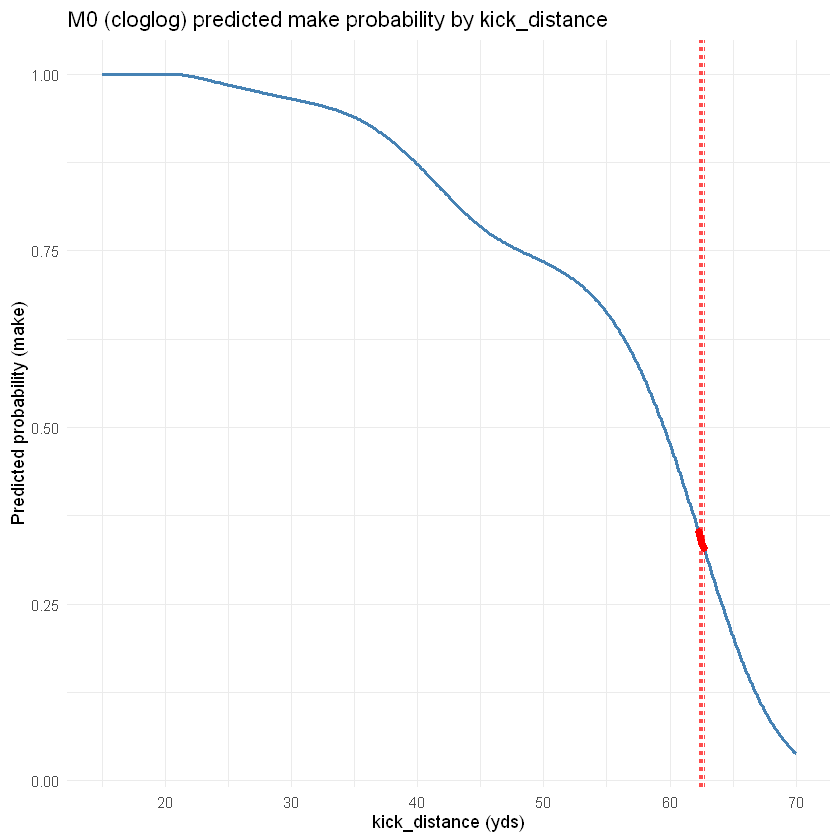

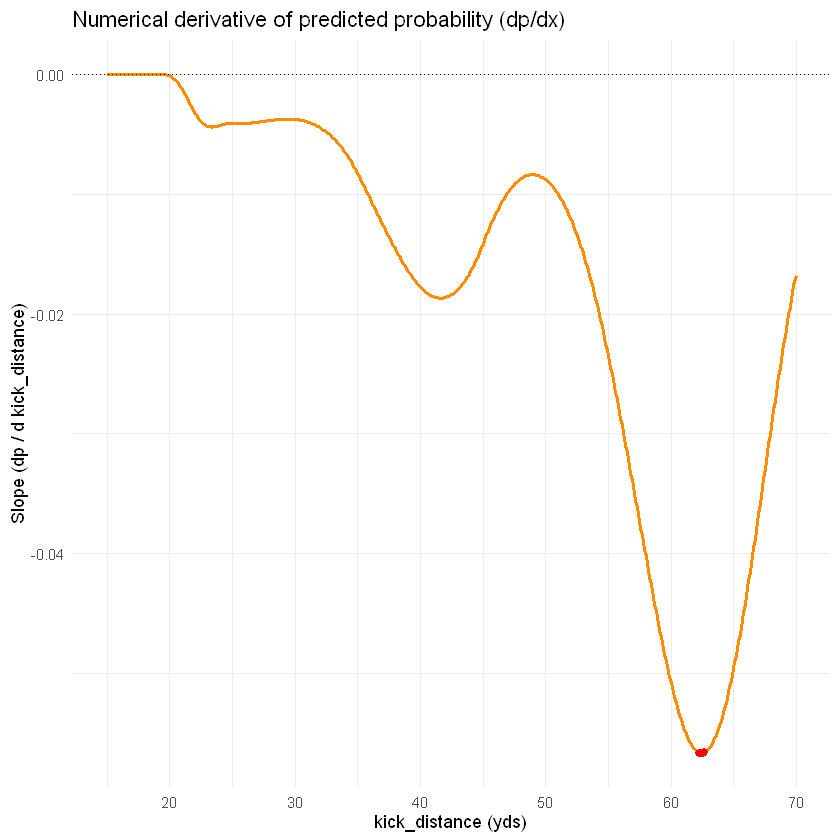

In [24]:
# Visualize m0_cloglog fit and find steepest negative slopes by distance

library(ggplot2)
library(dplyr)

# Fine grid over distances in support
grid_x <- seq(15, 70, by = 0.1)

# Build spline basis for the grid (re-uses make_dist_basis defined earlier)
bs_grid <- make_dist_basis(grid_x)
newdata_grid <- bind_cols(data.frame(kick_distance = grid_x), bs_grid)

# Predicted probability from cloglog model
p_grid <- as.numeric(predict(m0_cloglog, newdata = newdata_grid, type = "response"))

# Numerical derivative (central difference)
dx <- diff(grid_x)
dp_forward <- diff(p_grid) / dx
# allocate derivative vector same length as grid_x (use central differences)
dp <- numeric(length(grid_x))
dp[1] <- dp_forward[1]
dp[length(grid_x)] <- dp_forward[length(dp_forward)]
dp[2:(length(grid_x)-1)] <- (p_grid[3:length(p_grid)] - p_grid[1:(length(p_grid)-2)]) /
                            (grid_x[3:length(grid_x)] - grid_x[1:(length(grid_x)-2)])

# Find most negative slopes (steepest downward)
n_show <- 5
idx_neg <- order(dp)[1:n_show]
steep_tbl <- tibble(
  kick_distance = grid_x[idx_neg],
  slope = dp[idx_neg]
) %>% arrange(slope)

# Print top steep negative points
print(steep_tbl)

# Prepare plotting data
plot_df <- tibble(kick_distance = grid_x, prob = p_grid, slope = dp)

# Plot probability curve with vertical lines at steepest points
p_prob <- ggplot(plot_df, aes(x = kick_distance, y = prob)) +
  geom_line(color = "steelblue", size = 1) +
  geom_vline(xintercept = steep_tbl$kick_distance, color = "red", linetype = "dashed", alpha = 0.7) +
  geom_point(data = steep_tbl, aes(x = kick_distance, y = approx(grid_x, p_grid, xout = kick_distance)$y),
             color = "red", size = 2) +
  labs(title = "M0 (cloglog) predicted make probability by kick_distance",
       x = "kick_distance (yds)",
       y = "Predicted probability (make)") +
  theme_minimal()

# Plot derivative (slope) curve and highlight steepest negative points
p_slope <- ggplot(plot_df, aes(x = kick_distance, y = slope)) +
  geom_line(color = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dotted") +
  geom_point(data = steep_tbl, aes(x = kick_distance, y = slope), color = "red", size = 2) +
  labs(title = "Numerical derivative of predicted probability (dp/dx)",
       x = "kick_distance (yds)",
       y = "Slope (dp / d kick_distance)") +
  theme_minimal()

# Print plots (in a notebook these will display one after the other)
print(p_prob)
print(p_slope)

## M1 - GLM Variable Tuning

In [ ]:
# Build modeling frame (same transforms as before)
fg_attempts_mm1 <- fg_attempts_mm %>%
  mutate(
    kick_made = as.integer(kick_result == "made"),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id),
    indoors = as.integer(indoors),
    is_turf = as.integer(is_turf),
    high_altitude = as.integer(high_altitude),
    is_rain_showers = as.integer(is_rain_showers),
    is_snow_sleet = as.integer(is_snow_sleet),
    is_cloudy = as.integer(is_cloudy),
    is_hazy_fog = as.integer(is_hazy_fog),
    clock_running = as.integer(clock_running),
    posteam_timeouts_remaining = as.integer(posteam_timeouts_remaining),
    iced = as.integer(iced),
    is_ot = as.integer(is_ot),
    leverage_z = if_else(is.na(leverage_z), 0, leverage_z),
    kicker_age_z = if_else(is.na(kicker_age_z), 0, kicker_age_z),
    kicker_experience_z = if_else(is.na(kicker_experience_z), 0, kicker_experience_z),
    season_type = factor(season_type)
  ) %>%
  bind_cols(make_dist_basis(.$kick_distance))

bs_cols <- grep("^bs_", names(fg_attempts_mm1), value = TRUE)

# Main distance term:
dist_term   <- paste(bs_cols, collapse = " + ")
# Interactions:
wind_terms  <- paste(paste0(bs_cols, ":wind_z"), collapse = " + ")
temp_terms  <- paste(paste0(bs_cols, ":temp_z"), collapse = " + ")
feature_candidates <- c(
    bs_cols,
  # Environment
  "indoors","is_turf","high_altitude",
  "wind_z","temp_z","humidity_z",
  "is_snow_sleet","is_rain_showers","is_cloudy","is_hazy_fog",
  # Pressure / state
  "leverage_z","is_ot","clock_running","iced",
  "posteam_timeouts_remaining",
  # Identity & drift
  "kicker_age_z","kicker_experience_z","season_z"
)

X <- model.matrix(~ 0 + ., data = fg_attempts_mm1[, feature_candidates])
y <- fg_attempts_mm1$kick_made

# Grouped CV by game to avoid leakage
set.seed(1)
K <- 5
gid <- as.factor(fg_attempts_mm1$game_id)
levels(gid) <- sample(1:K, nlevels(gid), replace=TRUE)
foldid <- as.integer(gid)

cv <- cv.glmnet(X, y, family="binomial", alpha = 0.5, foldid = foldid)  # elastic net

fit <- glmnet(X, y, family="binomial", alpha = 0.5, lambda = cv$lambda.1se)

sel <- rownames(coef(fit))[which(coef(fit) != 0)]
sel <- setdiff(sel, "(Intercept)")
print('Selected features (1se):')
sel

# Looser than 1se:
fit_min <- glmnet(X, y, family="binomial", alpha=0.5, lambda=cv$lambda.min)

sel_min <- rownames(coef(fit_min))[which(coef(fit_min)!=0)]
sel_min <- setdiff(sel_min, "(Intercept)")
print('Selected features (min):')
sel_min

lambda_relaxed <- exp( 0.5*log(cv$lambda.min) + 0.5*log(cv$lambda.1se) )  # geometric mean
fit_relaxed <- glmnet(X, y, family="binomial", alpha=0.5, lambda=lambda_relaxed)
sel_relaxed <- setdiff(rownames(coef(fit_relaxed))[which(coef(fit_relaxed)!=0)], "(Intercept)")
print('Selected features (relaxed):')
sel_relaxed

[1] "Selected features (1se):"


[1] "bs_2"       "bs_4"       "bs_5"       "bs_6"       "bs_7"      
[6] "leverage_z"

[1] "Selected features (min):"


[1] "bs_1"                       "bs_2"                      
 [3] "bs_3"                       "bs_4"                      
 [5] "bs_5"                       "bs_6"                      
 [7] "bs_7"                       "indoors"                   
 [9] "is_turf"                    "high_altitude"             
[11] "wind_z"                     "temp_z"                    
[13] "humidity_z"                 "is_snow_sleet"             
[15] "is_rain_showers"            "is_cloudy"                 
[17] "is_hazy_fog"                "leverage_z"                
[19] "is_ot"                      "clock_running"             
[21] "iced"                       "posteam_timeouts_remaining"
[23] "kicker_age_z"               "kicker_experience_z"       
[25] "season_z"

[1] "Selected features (relaxed):"


[1] "bs_1"                       "bs_2"                      
 [3] "bs_3"                       "bs_4"                      
 [5] "bs_5"                       "bs_6"                      
 [7] "bs_7"                       "indoors"                   
 [9] "wind_z"                     "leverage_z"                
[11] "is_ot"                      "clock_running"             
[13] "iced"                       "posteam_timeouts_remaining"

In [ ]:
b <- as.matrix(coef(fit_min))[-1, , drop=FALSE]   # drop intercept
imp_tbl <- data.frame(
  feature = rownames(b),
  beta = as.numeric(b)
) |>
  dplyr::mutate(abs_beta = abs(beta)) |>
  dplyr::arrange(dplyr::desc(abs_beta))

head(imp_tbl, 30)  # top 30 features by absolute coefficient

imp_tbl |>
  dplyr::mutate(group = dplyr::case_when(
    grepl("^bs_", feature) ~ "distance_bs",
    feature %in% c("wind_z","temp_z","humidity_z","is_snow_sleet","is_rain_showers","is_cloudy","is_hazy_fog") ~ "weather",
    feature %in% c("indoors","is_turf","high_altitude") ~ "env",
    feature %in% c("leverage_z","clock_running","iced","is_ot","posteam_timeouts_remaining") ~ "pressure",
    feature %in% c("kicker_age_z","kicker_experience_z","season_z") ~ "drift",
    TRUE ~ "other"
  )) |>
  dplyr::group_by(group) |>
  dplyr::slice_max(abs_beta, n=10, with_ties=FALSE)
write.csv(imp_tbl, file=file.path(TUNING_DIR, "feature_importance.csv"), row.names=FALSE)


,feature,beta,abs_beta
,<chr>,<dbl>,<dbl>
1,bs_2,-11137.015284,11137.015284
2,is_snow_sleet,-7969.475464,7969.475464
3,is_rain_showers,-4601.596242,4601.596242
4,bs_4,4419.617321,4419.617321
5,bs_6,4214.091242,4214.091242
6,bs_5,3013.856664,3013.856664
7,indoors,2021.421032,2021.421032
8,is_turf,1632.833340,1632.833340
9,season_z,1573.043055,1573.043055


feature,beta,abs_beta,group
<chr>,<dbl>,<dbl>,<chr>
bs_2,-11137.015284,11137.015284,distance_bs
bs_4,4419.617321,4419.617321,distance_bs
bs_6,4214.091242,4214.091242,distance_bs
bs_5,3013.856664,3013.856664,distance_bs
bs_1,-1352.292260,1352.292260,distance_bs
bs_7,1267.959951,1267.959951,distance_bs
bs_3,431.662870,431.662870,distance_bs
season_z,1573.043055,1573.043055,drift
kicker_age_z,65.010514,65.010514,drift


In [ ]:
set.seed(42)
B <- 50
stab_list <- replicate(B, {
  # subsample by game to avoid leakage
  keep_ids <- sample(unique(fg_attempts_mm1$game_id),
                     size = floor(0.8*length(unique(fg_attempts_mm1$game_id))))
  idx <- fg_attempts_mm1$game_id %in% keep_ids
  Xb <- X[idx, , drop=FALSE]; yb <- y[idx]
  cvb <- cv.glmnet(Xb, yb, family="binomial", alpha=0.5, type.measure="deviance")
  fb  <- glmnet(Xb, yb, family="binomial", alpha=0.5, lambda=cvb$lambda.min)
  setdiff(rownames(coef(fb))[coef(fb)!=0], "(Intercept)")
}, simplify=FALSE)

stab_freq <- sort(table(unlist(stab_list))/B, decreasing=TRUE)
head(stab_freq, 40)
write.csv(as.data.frame(stab_freq), file=file.path(TUNING_DIR, "stab_freq.csv"))



                                    bs_2 
                                    1.00 
                            bs_2:indoors 
                                    1.00 
                                    bs_3 
                                    1.00 
                                    bs_4 
                                    1.00 
                            bs_4:indoors 
                                    1.00 
                    bs_4:is_rain_showers 
                                    1.00 
                                    bs_5 
                                    1.00 
                            bs_5:indoors 
                                    1.00 
                    bs_5:is_rain_showers 
                                    1.00 
                      bs_5:is_snow_sleet 
                                    1.00 
                                    bs_6 
                                    1.00 
                            bs_6:indoors 
                                 

In [ ]:
# Targeted interactions
int_pairs <- list(
  wind   = c(bs_cols, "wind_z"),
  temp   = c(bs_cols, "temp_z"),
  humid  = c(bs_cols, "humidity_z"),
  rain   = c(bs_cols, "is_rain_showers"),
  snow   = c(bs_cols, "is_snow_sleet"),
  indoor = c(bs_cols, "indoors"),
  leverage = c("leverage_z", "is_ot", "iced"),
  clock = c("clock_running","posteam_timeouts_remaining"),
  kicker = c("kicker_age_z","kicker_experience_z")
)

# Build interaction columns (center continuous vars first for stability)
zc <- function(v) as.numeric(scale(v, center = TRUE, scale = TRUE))

mk_int <- function(lhs, rhs) {
  L <- X[, lhs, drop = FALSE]
  r <- X[, rhs, drop = FALSE]
  # If rhs is a single column:
  if (ncol(r) == 1L) {
    out <- sweep(L, 1, r[,1], `*`)
    colnames(out) <- paste0(colnames(L), ":", colnames(r))
    return(out)
  }
  stop("rhs should be a single column in this helper.")
}

X_int <- cbind(
  mk_int(bs_cols, "wind_z"),
  mk_int(bs_cols, "temp_z"),
  mk_int(bs_cols, "humidity_z"),
  mk_int(bs_cols, "is_rain_showers"),
  mk_int(bs_cols, "is_snow_sleet"),
  mk_int(bs_cols, "indoors"),
  mk_int(c("is_ot", "iced"), "leverage_z"),
  mk_int("posteam_timeouts_remaining", "clock_running"),
  mk_int("kicker_experience_z", "kicker_age_z")
)

X_with_int <- cbind(X, X_int)
colnames(X_with_int)


[1] "bs_1"                                    
  [2] "bs_2"                                    
  [3] "bs_3"                                    
  [4] "bs_4"                                    
  [5] "bs_5"                                    
  [6] "bs_6"                                    
  [7] "bs_7"                                    
  [8] "indoors"                                 
  [9] "is_turf"                                 
 [10] "high_altitude"                           
 [11] "wind_z"                                  
 [12] "temp_z"                                  
 [13] "humidity_z"                              
 [14] "is_snow_sleet"                           
 [15] "is_rain_showers"                         
 [16] "is_cloudy"                               
 [17] "is_hazy_fog"                             
 [18] "leverage_z"                              
 [19] "is_ot"                                   
 [20] "clock_running"                           
 [21] "iced"                                    
 [22] "posteam_timeouts_remaining"              
 [23] "kicker_age_z"                            
 [24] "kicker_experience_z"                     
 [25] "season_z"                                
 [26] "bs_1:wind_z"                             
 [27] "bs_2:wind_z"                             
 [28] "bs_3:wind_z"                             
 [29] "bs_4:wind_z"                             
 [30] "bs_5:wind_z"                             
 [31] "bs_6:wind_z"                             
 [32] "bs_7:wind_z"                             
 [33] "bs_1:temp_z"                             
 [34] "bs_2:temp_z"                             
 [35] "bs_3:temp_z"                             
 [36] "bs_4:temp_z"                             
 [37] "bs_5:temp_z"                             
 [38] "bs_6:temp_z"                             
 [39] "bs_7:temp_z"                             
 [40] "bs_1:humidity_z"                         
 [41] "bs_2:humidity_z"                         
 [42] "bs_3:humidity_z"                         
 [43] "bs_4:humidity_z"                         
 [44] "bs_5:humidity_z"                         
 [45] "bs_6:humidity_z"                         
 [46] "bs_7:humidity_z"                         
 [47] "bs_1:is_rain_showers"                    
 [48] "bs_2:is_rain_showers"                    
 [49] "bs_3:is_rain_showers"                    
 [50] "bs_4:is_rain_showers"                    
 [51] "bs_5:is_rain_showers"                    
 [52] "bs_6:is_rain_showers"                    
 [53] "bs_7:is_rain_showers"                    
 [54] "bs_1:is_snow_sleet"                      
 [55] "bs_2:is_snow_sleet"                      
 [56] "bs_3:is_snow_sleet"                      
 [57] "bs_4:is_snow_sleet"                      
 [58] "bs_5:is_snow_sleet"                      
 [59] "bs_6:is_snow_sleet"                      
 [60] "bs_7:is_snow_sleet"                      
 [61] "bs_1:indoors"                            
 [62] "bs_2:indoors"                            
 [63] "bs_3:indoors"                            
 [64] "bs_4:indoors"                            
 [65] "bs_5:indoors"                            
 [66] "bs_6:indoors"                            
 [67] "bs_7:indoors"                            
 [68] "is_ot:leverage_z"                        
 [69] "iced:leverage_z"                         
 [70] "posteam_timeouts_remaining:clock_running"
 [71] "kicker_experience_z:kicker_age_z"        
 [72] "bs_1:wind_z"                             
 [73] "bs_2:wind_z"                             
 [74] "bs_3:wind_z"                             
 [75] "bs_4:wind_z"                             
 [76] "bs_5:wind_z"                             
 [77] "bs_6:wind_z"                             
 [78] "bs_7:wind_z"                             
 [79] "bs_1:temp_z"                             
 [80] "bs_2:temp_z"                             
 [81] "bs_3:temp_z"                             
 [82] "bs_4:temp_z"              

In [ ]:
# Penalty factors: smaller = keep easier, larger = penalize more
pf <- rep(1, ncol(X))
pf[colnames(X) %in% bs_cols] <- 0.5          # keep the spline backbone
pf[colnames(X) %in% colnames(X_int)] <- 1.5  # interactions earn their way in

set.seed(1)
# grouped CV by game to avoid leakage
K <- 5
gid <- as.factor(fg_attempts_mm1$game_id)
levels(gid) <- sample(1:K, nlevels(gid), replace = TRUE)
foldid <- as.integer(gid)

cv  <- cv.glmnet(X, y, family = "binomial", alpha = 0.5,
                 foldid = foldid, type.measure = "deviance",
                 penalty.factor = pf)
fit <- glmnet(X, y, family = "binomial", alpha = 0.5,
              lambda = cv$lambda.min, penalty.factor = pf)

nz  <- setdiff(rownames(coef(fit))[which(coef(fit) != 0)], "(Intercept)")
nz_main <- nz[nz %in% colnames(X_with_int) & !(nz %in% colnames(X_int))]
nz_int  <- nz[nz %in% colnames(X_int)]
print('Selected features with interactions (1se):')
print(nz)

# Rank by absolute coefficient at lambda.min
b <- as.matrix(coef(fit))[nz, , drop = FALSE]
imp <- data.frame(feature = nz, beta = as.numeric(b)) |>
  arrange(desc(abs(beta)))

imp_tbl <- imp %>%
  dplyr::mutate(abs_beta = abs(beta)) %>%
  dplyr::mutate(group = dplyr::case_when(
    grepl("^bs_", feature) ~ "distance_bs",
    feature %in% c("wind_z","temp_z","humidity_z","is_snow_sleet","is_rain_showers","is_cloudy","is_hazy_fog") ~ "weather",
    feature %in% c("indoors","is_turf","high_altitude") ~ "env",
    feature %in% c("leverage_z","clock_running","iced","is_ot","posteam_timeouts_remaining") ~ "pressure",
    grepl("x", feature) ~ "drift",   # features containing "x" map to drift
    TRUE ~ "other"
  )) %>%
  dplyr::group_by(group) %>%
  dplyr::ungroup()

imp_tbl
write.csv(imp_tbl, file=file.path(TUNING_DIR, "feature_importance_with_interactions.csv"), row.names=FALSE)

[1] "Selected features with interactions (1se):"
 [1] "bs_1"                                    
 [2] "bs_2"                                    
 [3] "bs_3"                                    
 [4] "bs_4"                                    
 [5] "bs_5"                                    
 [6] "bs_6"                                    
 [7] "bs_7"                                    
 [8] "indoors"                                 
 [9] "wind_z"                                  
[10] "leverage_z"                              
[11] "is_ot"                                   
[12] "clock_running"                           
[13] "iced"                                    
[14] "posteam_timeouts_remaining"              
[15] "bs_6:humidity_z"                         
[16] "bs_7:humidity_z"                         
[17] "bs_2:is_rain_showers"                    
[18] "bs_4:is_rain_showers"                    
[19] "bs_5:is_rain_showers"                    
[20] "bs_6:is_rain_showers"            

feature,beta,abs_beta,group
<chr>,<dbl>,<dbl>,<chr>
bs_7:is_rain_showers,-4165.963478,4165.963478,distance_bs
bs_2:is_rain_showers,3332.051438,3332.051438,distance_bs
bs_1,3138.399660,3138.399660,distance_bs
bs_7,-2001.652533,2001.652533,distance_bs
bs_6,-1554.410298,1554.410298,distance_bs
bs_2,1005.650003,1005.650003,distance_bs
bs_5,-697.348995,697.348995,distance_bs
bs_6:is_snow_sleet,-649.577191,649.577191,distance_bs
bs_4,-618.362826,618.362826,distance_bs


In [ ]:
set.seed(42)
B <- 50
stab_list_int <- replicate(B, {
  # subsample by game to avoid leakage
  keep_ids <- sample(unique(fg_attempts_mm1$game_id),
                     size = floor(0.8 * length(unique(fg_attempts_mm1$game_id))))
  idx <- fg_attempts_mm1$game_id %in% keep_ids

  Xb <- X_with_int[idx, , drop = FALSE]
  yb <- y[idx]

  # basic guards: remove cols with zero/NA variance, drop rows with missing y or X
  if (nrow(Xb) == 0 || length(yb) == 0) return(character(0))
  ok_cols <- vapply(seq_len(ncol(Xb)), function(j) {
    col <- Xb[, j]
    is.numeric(col) && !all(is.na(col)) && var(col, na.rm = TRUE) > 0
  }, logical(1))
  if (!any(ok_cols)) return(character(0))
  Xb2 <- Xb[, ok_cols, drop = FALSE]

  complete_rows <- complete.cases(Xb2) & !is.na(yb)
  Xb2 <- Xb2[complete_rows, , drop = FALSE]
  yb2 <- yb[complete_rows]

  # need at least some rows and both outcome classes
  if (nrow(Xb2) < 10 || length(unique(yb2)) < 2) return(character(0))

  # wrap glmnet in tryCatch so a single failure doesn't stop the loop
  vars <- tryCatch({
    cvb <- cv.glmnet(Xb2, yb2, family = "binomial", alpha = 0.5, type.measure = "deviance", nfolds = 5)
    fb  <- glmnet(Xb2, yb2, family = "binomial", alpha = 0.5, lambda = cvb$lambda.min)
    sel <- rownames(coef(fb))[which(as.numeric(coef(fb)) != 0)]
    setdiff(sel, "(Intercept)")
  }, error = function(e) character(0))

  vars
}, simplify = FALSE)

stab_freq_int <- sort(table(unlist(stab_list_int))/B, decreasing = TRUE)
head(stab_freq_int, 40)
write.csv(as.data.frame(stab_freq_int), file = file.path(TUNING_DIR, "stab_freq_int.csv"))

In [ ]:
mm1_glm_formula <- as.formula(paste(
  "kick_made ~",
  # distance + PAT
  dist_term, "+ is_pat +",
  # main weather/env
  "wind_z + temp_z + humidity_z + indoors + is_turf + high_altitude +",
  # rain/snow only (per your choice)
  "is_rain_showers + is_snow_sleet +",
  # pressure / state
  "leverage_z + is_ot + clock_running + iced + posteam_timeouts_remaining +",
  #kicker age/exp
  "kicker_age_z*kicker_experience_z +",
  # season and IDs as **factors** for this GLM
  "season + stadium_id + kicker_player_id +",
  # interactions worth keeping (targeted)
  wind_terms, "+", temp_terms
))

# 4) Fit GLM (logit) with factors for stadium/kicker
mm1_glm <- glm(mm1_glm_formula, data = df_m1, family = binomial())

# 5) Eval: AUC + 11-bin calibration (15–70 by 5 yards)
p_hat <- as.numeric(predict(mm1_glm, type = "response"))
auc_val <- as.numeric(pROC::auc(df_m1$kick_made, p_hat)); auc_val

bin_breaks <- seq(15, 70, by = 5)
bin_labels <- levels(cut(15:69, breaks = bin_breaks, right = FALSE, include.lowest = TRUE))

cal_tbl <- df_m1 %>%
  mutate(
    p_hat = p_hat,
    dist_bin = cut(kick_distance, breaks = bin_breaks, labels = bin_labels,
                   include.lowest = TRUE, right = FALSE)
  ) %>%
  group_by(dist_bin) %>%
  summarise(
    n = n(),
    mean_pred = mean(p_hat, na.rm = TRUE),
    actual    = mean(kick_made, na.rm = TRUE),
    abs_err   = abs(mean_pred - actual),
    .groups = "drop"
  )

auc_val
cal_tbl

#Save the model and its results
saveRDS(mm1_glm, file=file.path(RDS_DIR, "mm1_glm.rds"))
write.csv(cal_tbl, file=file.path(METRICS_DIR, "mm1_glm_calibration.csv"), row.names=FALSE)
write.csv(auc_val, file=file.path(METRICS_DIR, "mm1_glm_auc.csv"), row.names=FALSE)

Warning message:
"glm.fit: algorithm did not converge"
Warning message:
"glm.fit: fitted probabilities numerically 0 or 1 occurred"
Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] 0.7878575

[1] 0.7878575

dist_bin,n,mean_pred,actual,abs_err
<fct>,<int>,<dbl>,<dbl>,<dbl>
"[15,20)",53,0.9999945,1.0000000,5.513193e-06
"[20,25)",1063,0.9943489,0.9943556,6.728689e-06
"[25,30)",1404,0.9779702,0.9743590,3.611258e-03
"[30,35)",13930,0.9514224,0.9525485,1.126031e-03
"[35,40)",1628,0.9154184,0.9189189,3.500491e-03
"[40,45)",1546,0.8371597,0.8376455,4.858738e-04
"[45,50)",1588,0.7549033,0.7544081,4.952311e-04
"[50,55)",1328,0.7091826,0.7251506,1.596799e-02
"[55,60)",457,0.6281091,0.6017505,2.635857e-02


## M1: GLMER with Covariates (makes vs misses)


### Model specification


In [ ]:
# --- Enhanced eval/save with Brier, AIC, BIC --------------------
eval_save <- function(model, data, name_prefix,
                      rds_dir = RDS_DIR, metrics_dir = METRICS_DIR) {

  # pop vs cond predictions
  pred_pop  <- as.numeric(predict(model, newdata = data, type = "response", re.form = NA))
  pred_cond <- as.numeric(predict(model, newdata = data, type = "response", re.form = NULL))

  # AUC
  auc_pop  <- as.numeric(pROC::auc(data$kick_made, pred_pop))
  auc_cond <- as.numeric(pROC::auc(data$kick_made, pred_cond))

  # Brier score
  brier_pop  <- mean((pred_pop  - data$kick_made)^2, na.rm = TRUE)
  brier_cond <- mean((pred_cond - data$kick_made)^2, na.rm = TRUE)

  # Model criteria (same for pop/cond)
  aic     <- AIC(model)
  bic     <- tryCatch(BIC(model), error = function(e) NA_real_)
  loglik  <- tryCatch(as.numeric(logLik(model)), error = function(e) NA_real_)
  nparams <- tryCatch(attr(logLik(model), "df"), error = function(e) NA_integer_)
  nobs    <- nobs(model)

  # Calibration: 11 fixed 5-yd bins [15,20), ... [65,70]
  bin_breaks <- seq(15, 70, by = 5)
  bin_labels <- levels(cut(15:69, breaks = bin_breaks, right = FALSE, include.lowest = TRUE))

  calibrate <- function(p) {
    data %>%
      mutate(
        p_hat = p,
        dist_bin = cut(kick_distance, breaks = bin_breaks, labels = bin_labels,
                       include.lowest = TRUE, right = FALSE)
      ) %>%
      group_by(dist_bin) %>%
      summarise(
        n = n(),
        mean_pred = mean(p_hat, na.rm = TRUE),
        actual    = mean(kick_made, na.rm = TRUE),
        abs_err   = abs(mean_pred - actual),
        .groups = "drop"
      )
  }
  cal_pop  <- calibrate(pred_pop)
  cal_cond <- calibrate(pred_cond)

  # Metrics table (two rows: pop/cond)
  metrics <- tibble::tibble(
    model      = c(paste0(name_prefix, "_pop"), paste0(name_prefix, "_cond")),
    auc        = c(auc_pop, auc_cond),
    brier      = c(brier_pop, brier_cond),
    AIC        = aic,
    BIC        = bic,
    logLik     = loglik,
    df_model   = nparams,
    nobs       = nobs
  )

  # Save artifacts
  saveRDS(model, file = file.path(rds_dir, paste0(name_prefix, ".rds")))
  write.csv(cal_pop,  file = file.path(metrics_dir, paste0(name_prefix, "_calibration_pop.csv")),  row.names = FALSE)
  write.csv(cal_cond, file = file.path(metrics_dir, paste0(name_prefix, "_calibration_cond.csv")), row.names = FALSE)
  write.csv(metrics,  file = file.path(metrics_dir, paste0(name_prefix, "_metrics.csv")),          row.names = FALSE)

  invisible(list(metrics = metrics, cal_pop = cal_pop, cal_cond = cal_cond))
}

In [27]:
# Modeling frame (made/missed only)
df_glmer_mm <- fg_attempts_mm %>%
  mutate(
    kick_made = as.integer(kick_result == "made"),
    kick_distance = as.numeric(kick_distance),
    is_pat = as.integer(is_pat == 1 | kick_distance == 33),
    # env & weather
    indoors = as.integer(indoors),
    is_turf = as.integer(is_turf),
    high_altitude = as.integer(high_altitude),
    wind_z = wind_z, temp_z = temp_z, humidity_z = humidity_z,
    is_rain_showers = as.integer(is_rain_showers),
    is_snow_sleet  = as.integer(is_snow_sleet),
    # pressure / state
    leverage_z = ifelse(is.na(leverage_z), 0, leverage_z),
    is_ot = as.integer(is_ot),
    clock_running = as.integer(clock_running),
    iced = as.integer(iced),
    posteam_timeouts_remaining = posteam_timeouts_remaining,
    # kicker drift
    kicker_age_z = ifelse(is.na(kicker_age_z), 0, kicker_age_z),
    kicker_experience_z = ifelse(is.na(kicker_experience_z), 0, kicker_experience_z),
    # IDs & season
    season = factor(season),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id)
  ) %>%
  bind_cols(make_dist_basis(.$kick_distance))

# --- GLMM formula (your fixed effects + random intercepts) ---------------
mm1_glmer_formula <- as.formula(paste(
  "kick_made ~",
  # distance + PAT
  dist_term, "+ is_pat +",
  # main weather/env
  "wind_z + temp_z + humidity_z + indoors + is_turf + high_altitude +",
  # rain/snow only
  "is_rain_showers + is_snow_sleet +",
  # pressure / state
  "leverage_z + is_ot + clock_running + iced + posteam_timeouts_remaining +",
  # kicker drift
  "kicker_age_z*kicker_experience_z +",
  # season as fixed effect
  "season +",
  # targeted interactions
  wind_terms, "+", temp_terms, "+",
  # random effects
  "(1 | stadium_id) + (1 | kicker_player_id)"
))


### Fit logit GLMER


In [118]:
# --- Fit GLMM ------------------------------------------------------------
#ctrl_logit <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5))
#m_glmer_logit <- glmer(mm1_glmer_formula, data = df_glmer_mm,
#                 family = binomial(link = "logit"), control = ctrl_logit)

summary(m_glmer_logit)
isSingular(m_glmer_logit, tol = 1e-4)

# --- Evaluation: AUC + 11-bin calibration -------------------------------
# Two views: population-level vs including RE
pred_pop  <- as.numeric(predict(m_glmer_logit, newdata = df_glmer_mm, type = "response", re.form = NA))
pred_cond <- as.numeric(predict(m_glmer_logit, newdata = df_glmer_mm, type = "response", re.form = NULL))

auc_pop  <- as.numeric(pROC::auc(df_glmer_mm$kick_made, pred_pop))
auc_cond <- as.numeric(pROC::auc(df_glmer_mm$kick_made, pred_cond))
print(auc_pop); print(auc_cond)

bin_breaks <- seq(15, 70, by = 5)
bin_labels <- levels(cut(15:69, breaks = bin_breaks, right = FALSE, include.lowest = TRUE))

calibrate <- function(p) {
  df_glmer_mm %>%
    mutate(
      p_hat = p,
      dist_bin = cut(kick_distance, breaks = bin_breaks, labels = bin_labels,
                     include.lowest = TRUE, right = FALSE)
    ) %>%
    group_by(dist_bin) %>%
    summarise(
      n = n(),
      mean_pred = mean(p_hat, na.rm = TRUE),
      actual    = mean(kick_made, na.rm = TRUE),
      abs_err   = abs(mean_pred - actual),
      .groups = "drop"
    )
}

cal_pop  <- calibrate(pred_pop)
cal_cond <- calibrate(pred_cond)

# Print calibration table
mm1_glmer_metrics <- tibble(
  model = c("MM1_glmer_pop", "MM1_glmer_cond"),
  auc = c(auc_pop, auc_cond)
)
mm1_glmer_metrics

#Save the model and its results
saveRDS(m_glmer_logit, file=file.path(RDS_DIR, "mm1_glmer_logit.rds"))
write.csv(cal_pop, file=file.path(METRICS_DIR, "mm1_glmer_logit_calibration_pop.csv"), row.names=FALSE)
write.csv(cal_cond, file=file.path(METRICS_DIR, "mm1_glmer_logit_calibration_cond.csv"), row.names=FALSE)
write.csv(mm1_glmer_metrics, file=file.path(METRICS_DIR, "mm1_glmer_logit_auc.csv"), row.names=FALSE)


Correlation matrix not shown by default, as p = 48 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: kick_made ~ bs_1 + bs_2 + bs_3 + bs_4 + bs_5 + bs_6 + bs_7 +  
    is_pat + wind_z + temp_z + humidity_z + indoors + is_turf +  
    high_altitude + is_rain_showers + is_snow_sleet + leverage_z +  
    is_ot + clock_running + iced + posteam_timeouts_remaining +  
    kicker_age_z * kicker_experience_z + season + bs_1:wind_z +  
    bs_2:wind_z + bs_3:wind_z + bs_4:wind_z + bs_5:wind_z + bs_6:wind_z +  
    bs_7:wind_z + bs_1:temp_z + bs_2:temp_z + bs_3:temp_z + bs_4:temp_z +  
    bs_5:temp_z + bs_6:temp_z + bs_7:temp_z + (1 | stadium_id) +  
    (1 | kicker_player_id)
   Data: df_glmer_mm
Control: ctrl_logit

      AIC       BIC    logLik -2*log(L)  df.resid 
  11964.8   12367.1   -5932.4   11864.8     23021 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-18.2792   0.1771   0.2191   0.2703   2.0867 

Random effects:
 Groups           N

[1] FALSE

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



[1] 0.7674006
[1] 0.7832343


model,auc
<chr>,<dbl>
MM1_glmer_pop,0.7674006
MM1_glmer_cond,0.7832343


### Fit cloglog GLMER


In [126]:
# Ensure tail60 exists (yards beyond 60; 0 otherwise)
df_glmer_mm <- df_glmer_mm %>%
  mutate(tail60 = pmax(as.numeric(kick_distance) - 60, 0))
  
# Formula: same as your logit spec + tail60 main effect and interactions
mm1_glmer_cll_formula <- as.formula(paste(
  "kick_made ~",
  # distance + PAT
  dist_term, "+ is_pat +",
  # main weather/env
  "wind_z + temp_z + indoors + high_altitude +",
  # rain/snow only
  "is_rain_showers + is_snow_sleet +",
  # pressure / state
  "leverage_z + is_ot + iced + clock_running*posteam_timeouts_remaining +",
  # kicker age/exp (incl their interaction, since you used it)
  "kicker_age_z*kicker_experience_z + ",
  # season_z as fixed effect
  "season_z +",
  # distance×weather interactions
  wind_terms, "+",
  # tail60 main + interactions
  "tail60 +",
  # random intercepts
  "(1 | stadium_id) + (1 | kicker_player_id)"
))


In [128]:
# install.packages("glmmTMB")  # if needed
library(glmmTMB)

m_cll_tmb <- glmmTMB(
  formula = mm1_glmer_cll_formula,
  data = df_glmer_mm,
  family = binomial(link = "cloglog")
)
summary(m_cll_tmb)

pred_pop_tmb  <- as.numeric(predict(m_cll_tmb, newdata = df_glmer_mm, type = "response", re.form = NA))
pred_cond_tmb <- as.numeric(predict(m_cll_tmb, newdata = df_glmer_mm, type = "response", re.form = NULL))
auc_pop_tmb   <- as.numeric(pROC::auc(df_glmer_mm$kick_made, pred_pop_tmb))
auc_cond_tmb  <- as.numeric(pROC::auc(df_glmer_mm$kick_made, pred_cond_tmb))

cal_pop  <- calibrate(pred_pop_tmb)
cal_cond <- calibrate(pred_cond_tmb)

mm1_glmer_cll_tmb_metrics <- tibble::tibble(
  model = c("MM1_glmer_cloglog_pop", "MM1_glmer_cloglog_cond"),
  auc   = c(auc_pop_tmb, auc_cond_tmb)
)
mm1_glmer_cll_tmb_metrics

# --- Save outputs (parallel to your logit files) -------------------------
saveRDS(m_cll_tmb, file = file.path(RDS_DIR, "mm1_glmer_cloglog_tmb.rds"))
write.csv(cal_pop,  file = file.path(METRICS_DIR, "mm1_glmer_cloglog_tmb_calibration_pop.csv"),  row.names = FALSE)
write.csv(cal_cond, file = file.path(METRICS_DIR, "mm1_glmer_cloglog_tmb_calibration_cond.csv"), row.names = FALSE)
write.csv(mm1_glmer_cll_tmb_metrics, file = file.path(METRICS_DIR, "mm1_glmer_cloglog_tmb_auc.csv"), row.names = FALSE)

 Family: binomial  ( cloglog )
Formula:          kick_made ~ bs_1 + bs_2 + bs_3 + bs_4 + bs_5 + bs_6 + bs_7 +  
    is_pat + wind_z + temp_z + indoors + high_altitude + is_rain_showers +  
    is_snow_sleet + leverage_z + is_ot + iced + clock_running *  
    posteam_timeouts_remaining + kicker_age_z * kicker_experience_z +  
    season_z + bs_1:wind_z + bs_2:wind_z + bs_3:wind_z + bs_4:wind_z +  
    bs_5:wind_z + bs_6:wind_z + bs_7:wind_z + tail60 + (1 | stadium_id) +  
    (1 | kicker_player_id)
Data: df_glmer_mm

      AIC       BIC    logLik -2*log(L)  df.resid 
  11959.1   12240.7   -5944.6   11889.1     23036 

Random effects:

Conditional model:
 Groups           Name        Variance  Std.Dev.
 stadium_id       (Intercept) 0.0006354 0.02521 
 kicker_player_id (Intercept) 0.0123447 0.11111 
Number of obs: 23071, groups:  stadium_id, 44; kicker_player_id, 112

Conditional model:
                                           Estimate Std. Error z value Pr(>|z|)
(Intercept)            

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



model,auc
<chr>,<dbl>
MM1_glmer_cloglog_pop,0.7653523
MM1_glmer_cloglog_cond,0.7825869


In [ ]:
mm1_fixed <- paste(
  c(
    dist_term,                  # distance + PAT
    "is_pat",
    "wind_z + temp_z + indoors + high_altitude",  # main weather/env
    "is_rain_showers + is_snow_sleet",           # rain/snow
    "leverage_z + is_ot + iced + clock_running * posteam_timeouts_remaining", # pressure/state
    "kicker_age_z * kicker_experience_z",        # kicker drift (with interaction)
    # "season_z",                                # optional
    wind_terms,                                   # distance × weather (wind)
    temp_terms                                    # distance × weather (temp)
    # "tail60 + tail60:wind_z + tail60:temp_z"   # optional tail60 terms
  ),
  collapse = " + "
)

mm1_re <- "(1 | stadium_id) + (1 | kicker_player_id)"

mm1_tmb_formula <- as.formula(paste("kick_made ~", mm1_fixed, "+", mm1_re))

# 3) Fit LOGIT with glmmTMB
m_tmb_logit <- glmmTMB(
  formula = mm1_tmb_formula,
  data    = df_glmer_mm,
  family  = binomial(link = "logit")
)
summary(m_tmb_logit)
logit_out <- eval_save(m_tmb_logit, df_glmer_mm, "mm1_glmmTMB_logit")
# 4) Fit CLOGLOG with glmmTMB
m_tmb_cloglog <- glmmTMB(
  formula = mm1_tmb_formula,
  data    = df_glmer_mm,
  family  = binomial(link = "cloglog")
)
summary(m_tmb_cloglog)
cll_out <- eval_save(m_tmb_cloglog, df_glmer_mm, "mm1_glmmTMB_cloglog")

logit_out$metrics
cll_out$metrics
logit_out$cal_cond
cll_out$cal_cond



 Family: binomial  ( logit )
Formula:          kick_made ~ bs_1 + bs_2 + bs_3 + bs_4 + bs_5 + bs_6 + bs_7 +  
    is_pat + wind_z + temp_z + indoors + high_altitude + is_rain_showers +  
    is_snow_sleet + leverage_z + is_ot + iced + clock_running *  
    posteam_timeouts_remaining + kicker_age_z * kicker_experience_z +  
    bs_1:wind_z + bs_2:wind_z + bs_3:wind_z + bs_4:wind_z + bs_5:wind_z +  
    bs_6:wind_z + bs_7:wind_z + bs_1:temp_z + bs_2:temp_z + bs_3:temp_z +  
    bs_4:temp_z + bs_5:temp_z + bs_6:temp_z + bs_7:temp_z + (1 |  
    stadium_id) + (1 | kicker_player_id)
Data: df_glmer_mm

      AIC       BIC    logLik -2*log(L)  df.resid 
  11961.9   12283.7   -5940.9   11881.9     23031 

Random effects:

Conditional model:
 Groups           Name        Variance Std.Dev.
 stadium_id       (Intercept) 0.004107 0.06409 
 kicker_player_id (Intercept) 0.088659 0.29776 
Number of obs: 23071, groups:  stadium_id, 44; kicker_player_id, 112

Conditional model:
                        

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



 Family: binomial  ( cloglog )
Formula:          kick_made ~ bs_1 + bs_2 + bs_3 + bs_4 + bs_5 + bs_6 + bs_7 +  
    is_pat + wind_z + temp_z + indoors + high_altitude + is_rain_showers +  
    is_snow_sleet + leverage_z + is_ot + iced + clock_running *  
    posteam_timeouts_remaining + kicker_age_z * kicker_experience_z +  
    bs_1:wind_z + bs_2:wind_z + bs_3:wind_z + bs_4:wind_z + bs_5:wind_z +  
    bs_6:wind_z + bs_7:wind_z + bs_1:temp_z + bs_2:temp_z + bs_3:temp_z +  
    bs_4:temp_z + bs_5:temp_z + bs_6:temp_z + bs_7:temp_z + (1 |  
    stadium_id) + (1 | kicker_player_id)
Data: df_glmer_mm

      AIC       BIC    logLik -2*log(L)  df.resid 
  11959.8   12281.7   -5939.9   11879.8     23031 

Random effects:

Conditional model:
 Groups           Name        Variance  Std.Dev.
 stadium_id       (Intercept) 0.0006461 0.02542 
 kicker_player_id (Intercept) 0.0132270 0.11501 
Number of obs: 23071, groups:  stadium_id, 44; kicker_player_id, 112

Conditional model:
                   

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



model,auc,brier,AIC,BIC,logLik,df_model,nobs
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
mm1_glmmTMB_logit_pop,0.7650919,0.07258170,11961.88,12283.73,-5940.941,40,23071
mm1_glmmTMB_logit_cond,0.7818952,0.07166047,11961.88,12283.73,-5940.941,40,23071


model,auc,brier,AIC,BIC,logLik,df_model,nobs
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
mm1_glmmTMB_cloglog_pop,0.7654982,0.07257687,11959.81,12281.67,-5939.906,40,23071
mm1_glmmTMB_cloglog_cond,0.7836246,0.07186333,11959.81,12281.67,-5939.906,40,23071


dist_bin,n,mean_pred,actual,abs_err
<fct>,<int>,<dbl>,<dbl>,<dbl>
"[15,20)",53,0.9999893,1.0000000,1.068940e-05
"[20,25)",1063,0.9946317,0.9943556,2.761086e-04
"[25,30)",1404,0.9781157,0.9743590,3.756725e-03
"[30,35)",13930,0.9525689,0.9525485,2.047021e-05
"[35,40)",1628,0.9167394,0.9189189,2.179475e-03
"[40,45)",1546,0.8397180,0.8376455,2.072468e-03
"[45,50)",1588,0.7580947,0.7544081,3.686602e-03
"[50,55)",1328,0.7119548,0.7251506,1.319582e-02
"[55,60)",457,0.6320811,0.6017505,3.033058e-02


dist_bin,n,mean_pred,actual,abs_err
<fct>,<int>,<dbl>,<dbl>,<dbl>
"[15,20)",53,0.9999430,1.0000000,5.696278e-05
"[20,25)",1063,0.9950270,0.9943556,6.714237e-04
"[25,30)",1404,0.9776075,0.9743590,3.248485e-03
"[30,35)",13930,0.9530569,0.9525485,5.084873e-04
"[35,40)",1628,0.9164648,0.9189189,2.454142e-03
"[40,45)",1546,0.8364833,0.8376455,1.162244e-03
"[45,50)",1588,0.7610276,0.7544081,6.619554e-03
"[50,55)",1328,0.7139643,0.7251506,1.118629e-02
"[55,60)",457,0.6266768,0.6017505,2.492630e-02


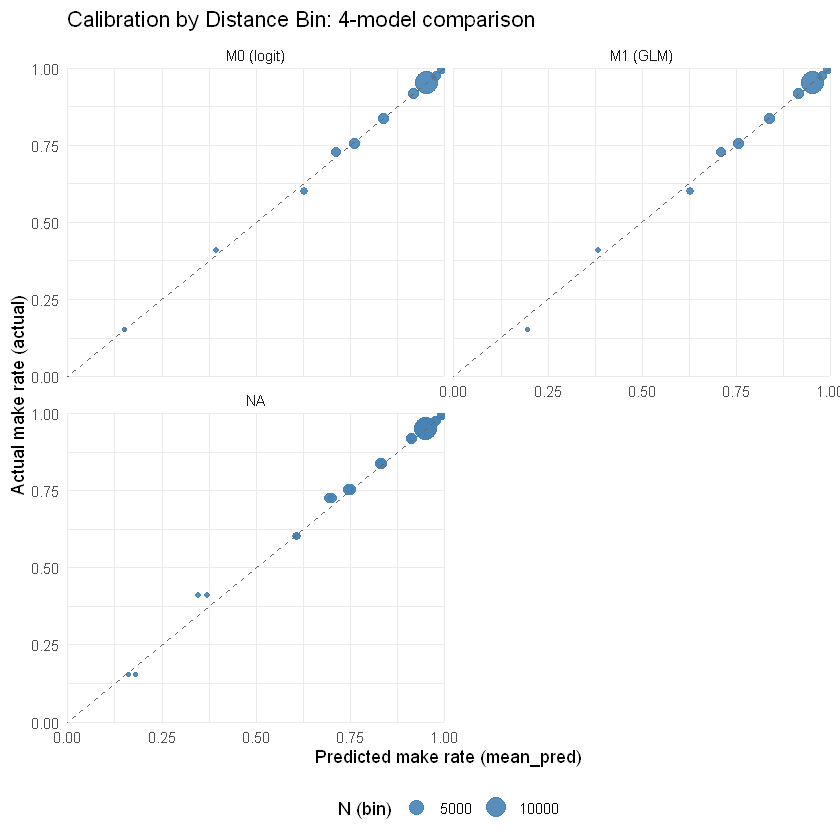

In [138]:
# Plot 4-panel calibration: M0 (logit), MM1 GLM, MM1 GLMER (logit, pop), MM1 GLMER cloglog (TMB, pop)
library(dplyr)
library(readr)
library(ggplot2)

# Helper to try multiple candidate filenames
try_read <- function(cands) {
  for (f in cands) {
    if (file.exists(f)) return(readr::read_csv(f, show_col_types = FALSE))
  }
  stop("None of the candidate files found:\n", paste(cands, collapse = "\n"))
}

# Candidate file lists (search common names written in earlier cells)
files <- list(
  m0 = c(file.path(METRICS_DIR, "m0_logit_calibration.csv"),
         file.path(METRICS_DIR, "calibration_m0_logit.csv"),
         file.path(METRICS_DIR, "m0_logit_calibration.csv")),
  mm1_glm = c(file.path(METRICS_DIR, "mm1_glm_calibration.csv"),
              file.path(METRICS_DIR, "m1_logit_calibration.csv"),
              file.path(METRICS_DIR, "m1_logit_calibration.csv")),
  mm1_glmmTMB_logit = c(file.path(METRICS_DIR, "mm1_glmmTMB_logit_calibration_pop.csv"),
                      file.path(METRICS_DIR, "mm1_glmmTMB_logit_calibration_cond.csv")),
  mm1_glmmTMB_cloglog = c(file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_calibration_pop.csv"),
                        file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_calibration_cond.csv"))
)

d_list <- list(
  M0_logit = try_read(files$m0) %>% mutate(model = "M0 (logit)"),
  M1_GLM = try_read(files$mm1_glm) %>% mutate(model = "M1 (GLM)"),
  MM1_glmmTMB_logit = try_read(files$mm1_glmmTMB_logit) %>% mutate(model = "MM1 GLMTMB logit (cond)"),
  MM1_glmmTMB_cloglog = try_read(files$mm1_glmmTMB_cloglog) %>% mutate(model = "MM1 GLMTMB cloglog (cond)")
)

# Ensure columns exist and standardize names (expect: dist_bin, n, mean_pred, actual)
standardise <- function(df) {
  # common fallback names
  if (!"mean_pred" %in% names(df) && "p_hat" %in% names(df)) df <- rename(df, mean_pred = p_hat)
  if (!"actual" %in% names(df) && "actual_rate" %in% names(df)) df <- rename(df, actual = actual_rate)
  df %>% select(any_of(c("dist_bin","n","mean_pred","actual", "model")))
}

df_all <- bind_rows(lapply(d_list, standardise))

# Make sure numeric and limits
df_all <- df_all %>%
  mutate(mean_pred = as.numeric(mean_pred),
         actual = as.numeric(actual),
         n = as.integer(n),
         model = factor(model, levels = c("M0 (logit)","M1 (GLM)",
                                          "MM1 GLTMB logit (cond)",
                                          "MM1 GLTMB cloglog (cond)")))

p_cal <- ggplot(df_all, aes(x = mean_pred, y = actual, size = pmax(1, n))) +
  geom_point(alpha = 0.9, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray40") +
  facet_wrap(~ model, ncol = 2) +
  scale_x_continuous(limits = c(0,1), expand = c(0,0)) +
  scale_y_continuous(limits = c(0,1), expand = c(0,0)) +
  labs(x = "Predicted make rate (mean_pred)", y = "Actual make rate (actual)",
       size = "N (bin)", title = "Calibration by Distance Bin: 4-model comparison") +
  theme_minimal() +
  theme(legend.position = "bottom")

print(p_cal)

# Save figure
if (!dir.exists(METRICS_FIG_DIR)) dir.create(METRICS_FIG_DIR, recursive = TRUE)
ggsave(filename = file.path(METRICS_FIG_DIR, "calibration_4panel.png"), plot = p_cal,
       width = 10, height = 7, dpi = 300)


## Cross-Validation for Top M1 Candidate


In [28]:
library(dplyr)
library(purrr)
library(tidyr)
library(glmmTMB)
library(pROC)
library(tibble)

# ---------- Config ----------
thr <- 0.5  # classification threshold for accuracy/recall/precision/F1

# ---------- Load prototype/best model ----------
proto_candidates <- c(
  file.path(RDS_DIR, "mm1_glmTMB_cloglog.rds"),
  file.path(RDS_DIR, "mm1_glmmTMB_cloglog.rds")
)
proto_path <- proto_candidates[file.exists(proto_candidates)][1]
if (is.na(proto_path)) stop("Best model RDS not found in RDS_DIR with expected names.")
mm1_proto <- readRDS(proto_path)

# ---------- Helpers ----------
refit_glmmTMB_from_proto <- function(proto, train_data) {
  cl <- proto$call
  cl$data <- quote(train_data)
  # ensure weights aren't inadvertently carried across if present in proto
  if ("weights" %in% names(as.list(cl))) cl$weights <- NULL
  eval(cl)
}

safe_auc <- function(truth, pred) {
  if (length(unique(truth)) < 2) return(NA_real_)
  as.numeric(pROC::auc(response = truth, predictor = pred, quiet = TRUE))
}

calib_glm <- function(truth, pred_prob) {
  if (length(unique(truth)) < 2) return(c(`(Intercept)` = NA_real_, fold_pred = NA_real_))
  fit <- glm(truth ~ pred_prob, family = binomial("logit"))
  cc  <- coef(fit)
  out <- c(`(Intercept)` = NA_real_, fold_pred = NA_real_)
  out[names(cc)] <- cc
  out
}

# Defensive division (returns NA on 0/0 or x/0)
safe_div <- function(num, den) ifelse(den > 0, num / den, NA_real_)

# ---------- 5-fold CV by game_id ----------
set.seed(20250928)
cv_games <- df_glmer_mm %>% distinct(game_id) %>%
  mutate(fold = sample(rep(1:5, length.out = n())))

cv_rows <- vector("list", length = 5)
cv_conf_list <- vector("list", length = 5)

for (fold_id in 1:5) {
  holdout_games <- cv_games %>% filter(fold == fold_id) %>% pull(game_id)
  train_data <- df_glmer_mm %>% filter(!game_id %in% holdout_games)
  test_data  <- df_glmer_mm %>% filter( game_id %in% holdout_games)

  # Refit
  fold_fit <- refit_glmmTMB_from_proto(mm1_proto, train_data)

  # Predict (population-level)
  fold_pred <- predict(fold_fit, newdata = test_data, type = "response", re.form = ~0)
  fold_truth <- test_data$kick_made

  # Prob-based metrics
  fold_auc   <- safe_auc(fold_truth, fold_pred)
  fold_brier <- mean((fold_pred - fold_truth)^2)

  # Threshold metrics
  yhat <- as.integer(fold_pred > thr)
  tp <- sum(yhat == 1 & fold_truth == 1, na.rm = TRUE)
  fp <- sum(yhat == 1 & fold_truth == 0, na.rm = TRUE)
  tn <- sum(yhat == 0 & fold_truth == 0, na.rm = TRUE)
  fn <- sum(yhat == 0 & fold_truth == 1, na.rm = TRUE)

  fold_accuracy  <- safe_div(tp + tn, tp + tn + fp + fn)
  fold_recall    <- safe_div(tp, tp + fn)
  fold_precision <- safe_div(tp, tp + fp)
  fold_f1 <- ifelse(is.na(fold_precision) | is.na(fold_recall) |
                      (fold_precision + fold_recall) == 0,
                    NA_real_,
                    2 * fold_precision * fold_recall / (fold_precision + fold_recall))

  # Confusion matrix (standard layout: rows=Actual 0/1, cols=Pred 0/1)
  cm <- matrix(c(tn, fp, fn, tp), nrow = 2, byrow = TRUE,
               dimnames = list(Actual = c("0","1"), Predicted = c("0","1")))
  cv_conf_list[[fold_id]] <- cm

  # Calibration
  cc <- calib_glm(fold_truth, fold_pred)
  calib_intercept <- unname(cc["(Intercept)"])
  calib_slope     <- unname(cc["fold_pred"])

  # Complexity (training fit)
  fold_aic <- AIC(fold_fit)
  fold_bic <- BIC(fold_fit)

  cv_rows[[fold_id]] <- tibble(
    fold = fold_id,
    n_train = nrow(train_data),
    n_test  = nrow(test_data),
    auc = fold_auc,
    brier = fold_brier,
    calib_intercept = calib_intercept,
    calib_slope     = calib_slope,
    aic = fold_aic,
    bic = fold_bic,
    accuracy = fold_accuracy,
    precision = fold_precision,
    recall = fold_recall,
    f1 = fold_f1
  )
}

cv_results_table <- bind_rows(cv_rows)

cv_summary <- cv_results_table %>%
  summarise(
    folds = n(),
    auc_mean   = mean(auc, na.rm = TRUE),
    auc_sd     = sd(auc,   na.rm = TRUE),
    brier_mean = mean(brier, na.rm = TRUE),
    brier_sd   = sd(brier,   na.rm = TRUE),
    calib_intercept_mean = mean(calib_intercept, na.rm = TRUE),
    calib_slope_mean     = mean(calib_slope,     na.rm = TRUE),
    aic_mean = mean(aic, na.rm = TRUE),
    bic_mean = mean(bic, na.rm = TRUE),
    accuracy_mean  = mean(accuracy,  na.rm = TRUE),
    precision_mean = mean(precision, na.rm = TRUE),
    recall_mean    = mean(recall,    na.rm = TRUE),
    f1_mean        = mean(f1,        na.rm = TRUE),
    accuracy_sd  = sd(accuracy,  na.rm = TRUE),
    precision_sd = sd(precision, na.rm = TRUE),
    recall_sd    = sd(recall,    na.rm = TRUE),
    f1_sd        = sd(f1,        na.rm = TRUE)
  )

# Sum confusion matrices across folds
cv_conf_mat_summary <- Reduce(`+`, cv_conf_list)

# ---------- Outputs ----------
cv_results_table
cv_summary
cv_conf_mat_summary

# Save CSVs
write.csv(cv_results_table, file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game.csv"), row.names = FALSE)
write.csv(cv_summary,       file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game_summary.csv"), row.names = FALSE)
write.csv(as.data.frame.matrix(cv_conf_mat_summary),
          file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game_confusion_matrix.csv"))


fold,n_train,n_test,auc,brier,calib_intercept,calib_slope,aic,bic,accuracy,precision,recall,f1
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18473,4598,0.7805951,0.07128396,-4.558162,NA,9665.512,9978.474,0.9127882,0.9144607,0.9976134,0.9542290
2,18432,4639,0.7679615,0.07072588,-4.410829,NA,9631.568,9944.442,0.9146368,0.9156757,0.9985852,0.9553350
3,18430,4641,0.7485013,0.07381670,-4.496175,NA,9517.018,9829.887,0.9090713,0.9115926,0.9966833,0.9522408
4,18451,4620,0.7423020,0.07455008,-4.250578,NA,9514.545,9827.459,0.9106061,0.9113814,0.9988098,0.9530948
5,18498,4573,0.7640989,0.07448454,-4.817392,NA,9570.285,9883.301,0.9077192,0.9096306,0.9973481,0.9514719


folds,auc_mean,auc_sd,brier_mean,brier_sd,calib_intercept_mean,calib_slope_mean,aic_mean,bic_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,accuracy_sd,precision_sd,recall_sd,f1_sd
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,0.7606918,0.01538989,0.07297223,0.001829354,-4.506627,NaN,9579.785,9892.713,0.9109643,0.9125482,0.997808,0.9532743,0.002786387,0.002460983,0.0008834808,0.001541638


,0,1
0,62,2008
1,46,20955


In [29]:
library(dplyr)
library(purrr)
library(tidyr)
library(glmmTMB)
library(pROC)
library(tibble)

# ---------- Config ----------
thr <- 0.5  # classification threshold for accuracy/recall/precision/F1

# ---------- Load prototype/best model ----------
proto_candidates <- c(
  file.path(RDS_DIR, "mm1_glmTMB_cloglog.rds"),
  file.path(RDS_DIR, "mm1_glmmTMB_cloglog.rds")
)
proto_path <- proto_candidates[file.exists(proto_candidates)][1]
if (is.na(proto_path)) stop("Best model RDS not found in RDS_DIR with expected names.")
mm1_proto <- readRDS(proto_path)

# ---------- Helpers ----------
refit_glmmTMB_from_proto <- function(proto, train_data) {
  cl <- proto$call
  cl$data <- quote(train_data)
  # ensure weights aren't inadvertently carried across if present in proto
  if ("weights" %in% names(as.list(cl))) cl$weights <- NULL
  eval(cl)
}

safe_auc <- function(truth, pred) {
  if (length(unique(truth)) < 2) return(NA_real_)
  as.numeric(pROC::auc(response = truth, predictor = pred, quiet = TRUE))
}

calib_glm <- function(truth, pred_prob) {
  if (length(unique(truth)) < 2) return(c(`(Intercept)` = NA_real_, fold_pred = NA_real_))
  fit <- glm(truth ~ pred_prob, family = binomial("logit"))
  cc  <- coef(fit)
  out <- c(`(Intercept)` = NA_real_, fold_pred = NA_real_)
  out[names(cc)] <- cc
  out
}

# Defensive division (returns NA on 0/0 or x/0)
safe_div <- function(num, den) ifelse(den > 0, num / den, NA_real_)

# ---------- 5-fold CV by game_id ----------
set.seed(20250928)
cv_games <- df_glmer_mm %>% distinct(game_id) %>%
  mutate(fold = sample(rep(1:5, length.out = n())))

cv_rows <- vector("list", length = 5)
cv_conf_list <- vector("list", length = 5)

for (fold_id in 1:5) {
  holdout_games <- cv_games %>% filter(fold == fold_id) %>% pull(game_id)
  train_data <- df_glmer_mm %>% filter(!game_id %in% holdout_games)
  test_data  <- df_glmer_mm %>% filter( game_id %in% holdout_games)

  # Refit
  fold_fit <- refit_glmmTMB_from_proto(mm1_proto, train_data)

  # Predict (population-level)
  fold_pred <- predict(fold_fit, newdata = test_data, type = "response", re.form = ~0)
  fold_truth <- test_data$kick_made

  # Prob-based metrics
  fold_auc   <- safe_auc(fold_truth, fold_pred)
  fold_brier <- mean((fold_pred - fold_truth)^2)

  # Threshold metrics
  opt_thr <- tryCatch({
    roc_obj <- pROC::roc(fold_truth, fold_pred, quiet = TRUE)
    coords(roc_obj, "best", best.method = "youden", transpose = FALSE)$threshold
  }, error = function(e) thr)
  yhat <- as.integer(fold_pred > opt_thr)
  tp <- sum(yhat == 1 & fold_truth == 1, na.rm = TRUE)
  fp <- sum(yhat == 1 & fold_truth == 0, na.rm = TRUE)
  tn <- sum(yhat == 0 & fold_truth == 0, na.rm = TRUE)
  fn <- sum(yhat == 0 & fold_truth == 1, na.rm = TRUE)

  fold_accuracy  <- safe_div(tp + tn, tp + tn + fp + fn)
  fold_recall    <- safe_div(tp, tp + fn)
  fold_precision <- safe_div(tp, tp + fp)
  fold_f1 <- ifelse(is.na(fold_precision) | is.na(fold_recall) |
                      (fold_precision + fold_recall) == 0,
                    NA_real_,
                    2 * fold_precision * fold_recall / (fold_precision + fold_recall))

  # Confusion matrix (standard layout: rows=Actual 0/1, cols=Pred 0/1)
  cm <- matrix(c(tn, fp, fn, tp), nrow = 2, byrow = TRUE,
               dimnames = list(Actual = c("0","1"), Predicted = c("0","1")))
  cv_conf_list[[fold_id]] <- cm

  # Calibration
  cc <- calib_glm(fold_truth, fold_pred)
  calib_intercept <- unname(cc["(Intercept)"])
  calib_slope     <- unname(cc["fold_pred"])

  # Complexity (training fit)
  fold_aic <- AIC(fold_fit)
  fold_bic <- BIC(fold_fit)

  cv_rows[[fold_id]] <- tibble(
    fold = fold_id,
    n_train = nrow(train_data),
    n_test  = nrow(test_data),
    auc = fold_auc,
    brier = fold_brier,
    calib_intercept = calib_intercept,
    calib_slope     = calib_slope,
    aic = fold_aic,
    bic = fold_bic,
    accuracy = fold_accuracy,
    precision = fold_precision,
    recall = fold_recall,
    f1 = fold_f1
  )
}

cv_results_table <- bind_rows(cv_rows)

cv_summary <- cv_results_table %>%
  summarise(
    folds = n(),
    auc_mean   = mean(auc, na.rm = TRUE),
    auc_sd     = sd(auc,   na.rm = TRUE),
    brier_mean = mean(brier, na.rm = TRUE),
    brier_sd   = sd(brier,   na.rm = TRUE),
    calib_intercept_mean = mean(calib_intercept, na.rm = TRUE),
    calib_slope_mean     = mean(calib_slope,     na.rm = TRUE),
    aic_mean = mean(aic, na.rm = TRUE),
    bic_mean = mean(bic, na.rm = TRUE),
    accuracy_mean  = mean(accuracy,  na.rm = TRUE),
    precision_mean = mean(precision, na.rm = TRUE),
    recall_mean    = mean(recall,    na.rm = TRUE),
    f1_mean        = mean(f1,        na.rm = TRUE),
    accuracy_sd  = sd(accuracy,  na.rm = TRUE),
    precision_sd = sd(precision, na.rm = TRUE),
    recall_sd    = sd(recall,    na.rm = TRUE),
    f1_sd        = sd(f1,        na.rm = TRUE)
  )

# Sum confusion matrices across folds
cv_conf_mat_summary <- Reduce(`+`, cv_conf_list)

# ---------- Outputs ----------
cv_results_table
cv_summary
cv_conf_mat_summary

# Save CSVs
write.csv(cv_results_table, file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game_optimal.csv"), row.names = FALSE)
write.csv(cv_summary,       file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game_summary_optimal.csv"), row.names = FALSE)
write.csv(as.data.frame.matrix(cv_conf_mat_summary),
          file = file.path(METRICS_DIR, "mm1_glmmTMB_cloglog_5foldcv_by_game_confusion_matrix_optimal.csv"))

fold,n_train,n_test,auc,brier,calib_intercept,calib_slope,aic,bic,accuracy,precision,recall,f1
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,18473,4598,0.7805951,0.07128396,-4.558162,NA,9665.512,9978.474,0.7831666,0.9623516,0.7930788,0.8695538
2,18432,4639,0.7679615,0.07072588,-4.410829,NA,9631.568,9944.442,0.7738737,0.9594128,0.7858996,0.8640311
3,18430,4641,0.7485013,0.07381670,-4.496175,NA,9517.018,9829.887,0.7968110,0.9530127,0.8168680,0.8797040
4,18451,4620,0.7423020,0.07455008,-4.250578,NA,9514.545,9827.459,0.7658009,0.9518980,0.7819567,0.8585991
5,18498,4573,0.7640989,0.07448454,-4.817392,NA,9570.285,9883.301,0.7920402,0.9542484,0.8095468,0.8759619


folds,auc_mean,auc_sd,brier_mean,brier_sd,calib_intercept_mean,calib_slope_mean,aic_mean,bic_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,accuracy_sd,precision_sd,recall_sd,f1_sd
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,0.7606918,0.01538989,0.07297223,0.001829354,-4.506627,NaN,9579.785,9892.713,0.7823385,0.9561847,0.79747,0.86957,0.01274176,0.004489921,0.01513236,0.008581908


,0,1
0,1302,768
1,4254,16747


In [30]:
opt_thr

[1] 0.8838205

'''

## Leave-one-game-out CV (LOOCV) using the same prototype

unique_games <- df_glmer_mm %>% distinct(game_id) %>% pull(game_id)
loocv_results <- vector("list", length = length(unique_games))

for (i in seq_along(unique_games)) {
  g <- unique_games[i]

  train_data <- df_glmer_mm %>% filter(game_id != g)
  test_data  <- df_glmer_mm %>% filter(game_id == g)

  loocv_fit  <- refit_glmmTMB_from_proto(mm1_proto, train_data)
  loocv_pred <- predict(loocv_fit, newdata = test_data, type = "response", re.form = ~0)

  loocv_truth <- test_data$kick_made
  loocv_auc   <- safe_auc(loocv_truth, loocv_pred)
  loocv_brier <- mean((loocv_pred - loocv_truth)^2)

  cc <- calib_glm(loocv_truth, loocv_pred)
  calib_intercept <- unname(cc["(Intercept)"])
  calib_slope     <- unname(cc["fold_pred"])

  ## AIC/BIC for the TRAINED model (on its train_data) for bookkeeping
  loocv_aic <- AIC(loocv_fit)
  loocv_bic <- BIC(loocv_fit)

  loocv_results[[i]] <- tibble(
    game_id = g,
    n_train = nrow(train_data),
    n_test  = nrow(test_data),
    auc = loocv_auc,
    brier = loocv_brier,
    calib_intercept = calib_intercept,
    calib_slope     = calib_slope,
    aic = loocv_aic,
    bic = loocv_bic
  )
}

loocv_results_table <- bind_rows(loocv_results)

loocv_summary <- loocv_results_table %>%
  summarise(
    games = n(),
    auc_mean   = mean(auc,   na.rm = TRUE),
    brier_mean = mean(brier, na.rm = TRUE),
    calib_intercept_mean = mean(calib_intercept, na.rm = TRUE),
    calib_slope_mean     = mean(calib_slope,     na.rm = TRUE),
    aic_mean = mean(aic, na.rm = TRUE),
    bic_mean = mean(bic, na.rm = TRUE)
  )

loocv_results_table
loocv_summary
'''

## M2: Incorporating Blocks


In [10]:

# --- Load prototype m1 (cloglog) ---
proto_path <- file.path(RDS_DIR, "mm1_glmmTMB_cloglog.rds")
mm1_proto  <- readRDS(proto_path)

# Helper: refit the saved model call on new data (optionally with weights)
refit_glmmTMB_from_proto <- function(proto, train_data, weights_vec = NULL) {
  cl <- proto$call
  cl$data <- quote(train_data)
  if (!is.null(weights_vec)) {
    cl$weights <- quote(weights_vec)
  } else if ("weights" %in% names(as.list(cl))) {
    cl$weights <- NULL
  }
  eval(cl)
}

# Safe AUC for quick in-sample check (no CV here)
safe_auc <- function(truth, pred) {
  if (length(unique(truth)) < 2) return(NA_real_)
  as.numeric(pROC::auc(response = truth, predictor = pred, quiet = TRUE))
}

# =========================
# 1) Normalize blocks df
# =========================
# Expect: fg_attempts_blocks has a text column `kick_result`
# Map to:
#   kick_made: 1 if "made", else 0 (miss + blocked → 0)
#   is_block : 1 if result contains "block", else 0

df_glmer_blocks <- fg_attempts_blocks %>%
  mutate(
    kick_result_std = tolower(trimws(kick_result)),
    is_block  = as.integer(grepl("blocked", kick_result_std)),
    kick_made = as.integer(kick_result_std == "made"),
    kick_distance = as.numeric(kick_distance),
    is_pat = as.integer(is_pat == 1 | kick_distance == 33),
    # env & weather
    indoors = as.integer(indoors),
    is_turf = as.integer(is_turf),
    high_altitude = as.integer(high_altitude),
    wind_z = wind_z, temp_z = temp_z, humidity_z = humidity_z,
    is_rain_showers = as.integer(is_rain_showers),
    is_snow_sleet  = as.integer(is_snow_sleet),
    # pressure / state
    leverage_z = ifelse(is.na(leverage_z), 0, leverage_z),
    is_ot = as.integer(is_ot),
    clock_running = as.integer(clock_running),
    iced = as.integer(iced),
    posteam_timeouts_remaining = posteam_timeouts_remaining,
    # kicker drift
    kicker_age_z = ifelse(is.na(kicker_age_z), 0, kicker_age_z),
    kicker_experience_z = ifelse(is.na(kicker_experience_z), 0, kicker_experience_z),
    # IDs & season
    season = factor(season),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id)
  ) %>%
  bind_cols(make_dist_basis(.$kick_distance))

# =========================
# 2) Variant A — m2 on blocks data (plain)
# =========================
m2_blocks_plain <- refit_glmmTMB_from_proto(mm1_proto, df_glmer_blocks)

# In-sample diagnostics (optional)
pred_A <- predict(m2_blocks_plain, newdata = df_glmer_blocks, type = "response", re.form = ~0)
truth  <- df_glmer_blocks$kick_made
diag_A <- tibble(
  model = "m2_blocks_plain",
  AIC = AIC(m2_blocks_plain),
  BIC = BIC(m2_blocks_plain),
  AUC = safe_auc(truth, pred_A),
  Brier = mean((pred_A - truth)^2)
)
print(diag_A)

# Save
saveRDS(m2_blocks_plain, file.path(RDS_DIR, "m2_blocks_plain_glmTMB_cloglog.rds"))

# =========================
# 3) Variant B — m2 weighted by m1 p-hat on blocked rows
# =========================

# 3.1 Get m1 probabilities on ALL rows of blocks df (population-level)
p_hat_m1_all <- predict(mm1_proto, newdata = df_glmer_blocks, type = "response", re.form = ~0)

# 3.2 Build weights: blocked → p_hat_m1; else → 1
eps <- 1e-4
p_hat_m1_all <- pmin(pmax(p_hat_m1_all, eps), 1 - eps)

df_glmer_blocks <- df_glmer_blocks %>%
  mutate(weight_b = if_else(is_block == 1L, p_hat_m1_all, 1.0))

# 3.3 Fit weighted model with same structure/family
m2_blocks_weighted <- refit_glmmTMB_from_proto(
  mm1_proto,
  train_data  = df_glmer_blocks,
  weights_vec = df_glmer_blocks$weight_b
)

# In-sample diagnostics (optional)
pred_B <- predict(m2_blocks_weighted, newdata = df_glmer_blocks, type = "response", re.form = ~0)
diag_B <- tibble(
  model = "m2_blocks_weighted",
  AIC = AIC(m2_blocks_weighted),
  BIC = BIC(m2_blocks_weighted),
  AUC = safe_auc(truth, pred_B),
  Brier = mean((pred_B - truth)^2)
)
print(diag_B)

# Save
saveRDS(m2_blocks_weighted, file.path(RDS_DIR, "m2_blocks_weighted_glmTMB_cloglog.rds"))

# =========================
# 4) (Optional) Compare quick in-sample summaries
# =========================
bind_rows(diag_A, diag_B)

# A tibble: 1 × 5
  model              AIC    BIC   AUC  Brier
  <chr>            <dbl>  <dbl> <dbl>  <dbl>
1 m2_blocks_plain 13313. 13635. 0.755 0.0810
# A tibble: 1 × 5
  model                 AIC    BIC   AUC  Brier
  <chr>               <dbl>  <dbl> <dbl>  <dbl>
1 m2_blocks_weighted 13175. 13497. 0.755 0.0810


model,AIC,BIC,AUC,Brier
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
m2_blocks_plain,13312.96,13635.33,0.7550799,0.08099123
m2_blocks_weighted,13175.00,13497.38,0.7550934,0.08096962


In [ ]:
fg_attempts_pathA <- fg_attempts %>%
  filter(kick_result %in% c("made", "missed")) %>%
  mutate(
    kick_made = if_else(kick_result == "made", 1L, 0L),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id),
    weight_pathA = 1 - prob_block
  )

m2_pathA_formula <- m1_formula_logit

m2_pathA_model <- glmer(
  formula = m2_pathA_formula,
  data = fg_attempts_pathA,
  family = binomial(link = "logit"),
  weights = weight_pathA,
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)

preds_m2_pathA <- predict(m2_pathA_model, newdata = fg_attempts_pathA, type = "response", allow.new.levels = TRUE)
truth_m2_pathA <- fg_attempts_pathA$kick_made
auc_m2_pathA <- as.numeric(pROC::auc(response = truth_m2_pathA, predictor = preds_m2_pathA, quiet = TRUE))
brier_m2_pathA <- mean((preds_m2_pathA - truth_m2_pathA)^2)

m2_pathA_metrics <- tibble(
  model = "M2_pathA_weighted",
  auc = auc_m2_pathA,
  brier = brier_m2_pathA
)

m2_pathA_metrics


In [ ]:
fg_attempts_pathB <- fg_attempts_blocks %>%
  filter(!is.na(kick_made_block0)) %>%
  mutate(
    kick_made_block0 = as.integer(kick_made_block0),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id)
  )

m2_pathB_formula <- kick_made_block0 ~
  dist_spline_1 + dist_spline_2 + dist_spline_3 + dist_spline_4 +
  dist_spline_5 + dist_spline_6 + dist_spline_7 + dist_spline_8 +
  wind_z + temp_z + humidity_z + indoors + is_turf + high_altitude +
  is_rain_showers + is_snow_sleet + is_cloudy + is_hazy_fog +
  l2m + clock_running + iced + kicker_age_z + kicker_experience_z +
  eog_urgency + go_ahead + to_tie + close7 +
  wind_z:dist_spline_1 + wind_z:dist_spline_2 + wind_z:dist_spline_3 + wind_z:dist_spline_4 +
  wind_z:dist_spline_5 + wind_z:dist_spline_6 + wind_z:dist_spline_7 + wind_z:dist_spline_8 +
  temp_z:dist_spline_1 + temp_z:dist_spline_2 + temp_z:dist_spline_3 + temp_z:dist_spline_4 +
  temp_z:dist_spline_5 + temp_z:dist_spline_6 + temp_z:dist_spline_7 + temp_z:dist_spline_8 +
  (1 | stadium_id) + (1 | kicker_player_id)

m2_pathB_model <- glmer(
  formula = m2_pathB_formula,
  data = fg_attempts_pathB,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)

preds_m2_pathB <- predict(m2_pathB_model, newdata = fg_attempts_pathB, type = "response", allow.new.levels = TRUE)
truth_m2_pathB <- fg_attempts_pathB$kick_made_block0
auc_m2_pathB <- as.numeric(pROC::auc(response = truth_m2_pathB, predictor = preds_m2_pathB, quiet = TRUE))
brier_m2_pathB <- mean((preds_m2_pathB - truth_m2_pathB)^2)

m2_pathB_metrics <- tibble(
  model = "M2_pathB_blocks_as_miss",
  auc = auc_m2_pathB,
  brier = brier_m2_pathB
)

m2_pathB_metrics


## M3: Incorporating Non-Attempts


In [ ]:
fg_nonattempts <- fg_nonattempts %>%
  mutate(
    stadium_id = if_else(is.na(stadium_id), "UNKNOWN", stadium_id),
    kicker_player_id = if_else(is.na(kicker_player_id), "UNKNOWN", kicker_player_id)
  )

spline_basis_nonattempts <- splines2::bSpline(fg_nonattempts$kick_distance,
                                              knots = m_knots,
                                              degree = 3,
                                              intercept = TRUE,
                                              Boundary.knots = boundary_knots)
colnames(spline_basis_nonattempts) <- paste0("dist_spline_", seq_len(ncol(spline_basis_nonattempts)))
fg_nonattempts <- bind_cols(fg_nonattempts, as_tibble(spline_basis_nonattempts))

attempt_model_data <- fg_attempts %>%
  select(game_id, play_id, attempted, kick_distance, starts_with("dist_spline_"), wind_z, temp_z, humidity_z,
         indoors, is_turf, high_altitude, is_rain_showers, is_snow_sleet, is_cloudy, is_hazy_fog,
         l2m, clock_running, iced, go_ahead, to_tie, close7, eog_urgency) %>%
  mutate(sample_group = "attempt") %>%
  bind_rows(
    fg_nonattempts %>%
      mutate(attempted = 0L,
             sample_group = "nonattempt") %>%
      select(game_id, play_id, attempted, kick_distance, starts_with("dist_spline_"), wind_z, temp_z, humidity_z,
             indoors, is_turf, high_altitude, is_rain_showers, is_snow_sleet, is_cloudy, is_hazy_fog,
             l2m, clock_running, iced, go_ahead, to_tie, close7, eog_urgency)
  )

m3_attempt_formula <- attempted ~
  dist_spline_1 + dist_spline_2 + dist_spline_3 + dist_spline_4 +
  dist_spline_5 + dist_spline_6 + dist_spline_7 + dist_spline_8 +
  wind_z + temp_z + humidity_z + indoors + is_turf + high_altitude +
  is_rain_showers + is_snow_sleet + is_cloudy + is_hazy_fog +
  l2m + clock_running + iced + go_ahead + to_tie + close7 + eog_urgency

m3_attempt_model <- glm(
  formula = m3_attempt_formula,
  data = attempt_model_data,
  family = binomial(link = "logit")
)

attempt_model_scores <- attempt_model_data %>%
  mutate(prob_attempt = predict(m3_attempt_model, type = "response")) %>%
  select(game_id, play_id, prob_attempt, sample_group)

fg_attempts_weighted <- fg_attempts_pathB %>%
  left_join(
    attempt_model_scores %>% filter(sample_group == "attempt") %>% select(-sample_group),
    by = c("game_id", "play_id")
  ) %>%
  mutate(
    prob_attempt = if_else(is.na(prob_attempt), 1, prob_attempt),
    stadium_id = factor(stadium_id),
    kicker_player_id = factor(kicker_player_id)
  )



In [ ]:
m3_weights <- fg_attempts_weighted$prob_attempt

m3_model <- glmer(
  formula = m2_pathB_formula,
  data = fg_attempts_weighted,
  family = binomial(link = "logit"),
  weights = m3_weights,
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)

preds_m3 <- predict(m3_model, newdata = fg_attempts_weighted, type = "response", allow.new.levels = TRUE)
truth_m3 <- fg_attempts_weighted$kick_made_block0
auc_m3 <- as.numeric(pROC::auc(response = truth_m3, predictor = preds_m3, quiet = TRUE))
brier_m3 <- mean((preds_m3 - truth_m3)^2)

m3_metrics <- tibble(
  model = "M3_weighted_attempts",
  auc = auc_m3,
  brier = brier_m3
)

m3_metrics


## Compile Metrics & Save Outputs


In [ ]:
metrics_table <- bind_rows(
  m0_logit_metrics,
  m0_cloglog_metrics,
  m1_logit_metrics,
  m1_cloglog_metrics,
  m1_reduced_metrics,
  m2_pathA_metrics,
  m2_pathB_metrics,
  m3_metrics
)

metrics_cv_summary <- cv_summary %>% mutate(model = "M1_logit_5fold")
metrics_loocv_summary <- loocv_summary %>% mutate(model = "M1_logit_LOOCV")

metrics_table
metrics_cv_summary
metrics_loocv_summary

readr::write_csv(metrics_table, file.path(METRICS_DIR, "model_metrics.csv"))
readr::write_csv(cv_results_table, file.path(METRICS_DIR, "m1_cv_results.csv"))
readr::write_csv(metrics_cv_summary, file.path(METRICS_DIR, "m1_cv_summary.csv"))
readr::write_csv(loocv_results_table, file.path(METRICS_DIR, "m1_loocv_results.csv"))
readr::write_csv(metrics_loocv_summary, file.path(METRICS_DIR, "m1_loocv_summary.csv"))


In [ ]:
readr::write_csv(m0_logit_calibration, file.path(METRICS_DIR, "calibration_m0_logit.csv"))
readr::write_csv(m0_cloglog_calibration, file.path(METRICS_DIR, "calibration_m0_cloglog.csv"))
readr::write_csv(m1_logit_calibration, file.path(METRICS_DIR, "calibration_m1_logit.csv"))
readr::write_csv(m1_cloglog_calibration, file.path(METRICS_DIR, "calibration_m1_cloglog.csv"))


In [ ]:
calibration_plot_m1 <- ggplot(m1_logit_calibration, aes(x = mean_pred, y = actual, size = n)) +
  geom_point(alpha = 0.8, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(title = "M1 Logit Calibration", x = "Predicted make rate", y = "Actual make rate") +
  theme_minimal()

calibration_plot_m0 <- ggplot(m0_logit_calibration, aes(x = mean_pred, y = actual, size = n)) +
  geom_point(alpha = 0.8, color = "darkorange") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(title = "M0 Logit Calibration", x = "Predicted make rate", y = "Actual make rate") +
  theme_minimal()

ggsave(filename = file.path(METRICS_FIG_DIR, "calibration_m1_logit.png"), plot = calibration_plot_m1, width = 7, height = 5, dpi = 300)
ggsave(filename = file.path(METRICS_FIG_DIR, "calibration_m0_logit.png"), plot = calibration_plot_m0, width = 7, height = 5, dpi = 300)


In [ ]:
saveRDS(m0_logit, file.path(RDS_DIR, "m0_logit.rds"))
saveRDS(m0_cloglog, file.path(RDS_DIR, "m0_cloglog.rds"))
saveRDS(m1_glmer_logit, file.path(RDS_DIR, "m1_glmer_logit.rds"))
saveRDS(m1_glmer_cloglog, file.path(RDS_DIR, "m1_glmer_cloglog.rds"))
saveRDS(m1_glmer_reduced, file.path(RDS_DIR, "m1_glmer_random_slope.rds"))
saveRDS(m2_pathA_model, file.path(RDS_DIR, "m2_pathA_weighted.rds"))
saveRDS(m2_pathB_model, file.path(RDS_DIR, "m2_pathB_blocks_as_miss.rds"))
saveRDS(m3_model, file.path(RDS_DIR, "m3_attempt_weighted.rds"))
saveRDS(m3_attempt_model, file.path(RDS_DIR, "m3_attempt_logit.rds"))
saveRDS(block_model, file.path(RDS_DIR, "block_probability_model.rds"))
